<a href="https://colab.research.google.com/github/hongxu-yn/Southeast-Asia-XCO2-STK/blob/main/Main_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 上传 github

In [15]:
import nbformat

# 1. 填入你的文件名
filename = '/content/drive/MyDrive/Colab Notebooks/Main_Reconstruction.ipynb'

import nbformat

# 1. 填入你的三个文件名
files_to_clean = [filename]

for file_path in files_to_clean:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)

        # 清除全局元数据中的 widgets
        nb.metadata.pop('widgets', None)

        for cell in nb.cells:
            # 1. 清除单元格元数据中的 widgets
            if 'metadata' in cell:
                cell.metadata.pop('widgets', None)

            # 2. 关键步骤：清空所有单元格的输出内容 (Outputs)
            # GitHub 报错通常是因为输出里存了无法渲染的交互进度条
            if cell.cell_type == 'code':
                cell.outputs = []
                cell.execution_count = None

        # 保存为新文件，加个后缀以防搞混
        new_name = file_path.replace('.ipynb', '_final.ipynb')
        with open(new_name, 'w', encoding='utf-8') as f:
            nbformat.write(nb, f)
        print(f"✅ {new_name} 已生成，这个文件绝对可以打开！")

    except Exception as e:
        print(f"❌ 处理 {file_path} 出错: {e}")

✅ /content/drive/MyDrive/Colab Notebooks/Main_Reconstruction_final.ipynb 已生成，这个文件绝对可以打开！


In [11]:
!ls

step01_QA_Control  step02_grid	step03_Keeling_curve


In [7]:
# 1. 进入目录
%cd /content/Southeast-Asia-XCO2-STK

# 2. 清除之前已经 add 进缓存的所有文件（别担心，本地文件不会丢）
!git rm -r --cached .

# 3. 创建黑名单：忽略所有 .csv 和 .nc 数据文件
with open(".gitignore", "w") as f:
    f.write("*.csv\n")
    f.write("*.nc\n")
    f.write("drive/\n")
    f.write(".ipynb_checkpoints/\n")

print("✅ 已创建 .gitignore，数据文件将被忽略")

/content/Southeast-Asia-XCO2-STK
fatal: pathspec '.' did not match any files
✅ 已创建 .gitignore，数据文件将被忽略


In [ ]:
!git add step01_QA_Control
!git commit -m "upload step01_QA_Control"
!git push origin main

# 初始化

In [8]:
from google.colab import drive
import os
import shutil
from pathlib import Path
!pip install -q netCDF4 joblib tqdm xarray pykrige gstools cartopy scipy
#!pip install cdsapi
#!apt-get install cdo -y
drive.mount('/content/drive')
print("✅ Drive 挂载成功且环境初始化完成！")

sea_extent = [87, 148, -16, 33]

RAW_DATA_ROOT = Path("/content/drive/MyDrive/project_01_XCO2数据集构建/co2_obs") #下载的卫星L2产品

PROJECT_DIR=Path("/content/Local-Spatio-Temporal-Kriging-of-XCO2-in-Southeast-Asia")
step01_QA_PATH = PROJECT_DIR / "step01_QA_Control"
step01_QA_PATH.mkdir(parents=True, exist_ok=True)

step02_grid_path = PROJECT_DIR / "step02_grid"
step02_grid_path.mkdir(parents=True, exist_ok=True)

step03_Keeling_curve_path = PROJECT_DIR / "step03_Keeling_curve"
step03_Keeling_curve_path.mkdir(parents=True, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive 挂载成功且环境初始化完成！


# Step_1_读取卫星数据_质控（OCO2_L2_Lite_FP 格式nc 转csv   cn_extent= [94.0, 134.0, 10.0, 54.0]中国extent 质控 #94.0, 135.0, 10.0, 54.0


In [ ]:
#质控
import gc
import os
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor


SEA_EXTENT = [87, 148, -16, 33]
OUT_PATH=step01_QA_PATH

# ==================== 1. 数据集配置 ====================
DATASETS = {
    "OCO2": {  # 修正：之前误写为 OCO3
        "short": "oco2_L2_Lite_FP",
        "start": 2014,
        "path": RAW_DATA_ROOT / "oco2_L2_Lite_FP_11.2r"
    },
    "OCO3": {
        "short": "oco3_L2_Lite_FP",
        "start": 2019,
        "path": RAW_DATA_ROOT / "oco3_L2_Lite_FP.11r"
    }
}

N_WORKERS = min(8, os.cpu_count() or 4)

# ==================== 2. 核心处理函数 ====================
def process_file_fast(f_path):
    try:
        with h5py.File(f_path, "r") as f:
            xco2 = f["xco2"][:]
            lon  = f["longitude"][:]
            lat  = f["latitude"][:]
            qf   = f["xco2_quality_flag"][:]
            time = f["time"][:]

            # 使用东南亚范围进行掩码过滤
            mask = (
                (lon >= SEA_EXTENT[0]) & (lon <= SEA_EXTENT[1]) &
                (lat >= SEA_EXTENT[2]) & (lat <= SEA_EXTENT[3]) &
                (qf == 0)
            )

            if np.sum(mask) == 0:
                return None

            df = pd.DataFrame({
                "xco2": xco2[mask],
                "longitude": lon[mask],
                "latitude": lat[mask],
                # 将底层秒数转换为标准时间
                "time": pd.to_datetime(time[mask], unit='s')
            })
            return df
    except Exception as e:
        # print(f"[WARN] failed: {f_path}\n  {e}") # 生产环境建议保持安静或记录日志
        return None

# ==================== 3. 主循环逻辑 ====================
for name, info in DATASETS.items():
    # 遍历年份（直到当前年份）
    for year in range(info["start"], 2026):
        y_path = info["path"] / str(year)
        s_path = OUT_PATH / f"{info['short']}_{year}.csv"

        if not y_path.exists():
            continue

        if s_path.exists():
            print(f"⏩ 跳过已存在: {s_path.name}")
            continue

        # 递归寻找文件夹下的所有 nc 或 hdf5 文件
        files = sorted(list(y_path.rglob("*.nc*")))
        if not files:
            print(f"❓ {name} {year} 年份目录下未找到文件")
            continue

        print(f"\n🚀 正在处理 {name} {year} | 东南亚区域 | 共 {len(files)} 个文件")

        results = []
        with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
            # 使用 tqdm 显示单个年份的处理进度
            for res in tqdm(executor.map(process_file_fast, files),
                            total=len(files),
                            desc=f"进度 {name}-{year}"):
                if res is not None:
                    results.append(res)

        # 合并当前年份的所有结果并保存
        if results:
            out_df = pd.concat(results, ignore_index=True)
            out_df.sort_values("time", inplace=True)
            out_df.to_csv(s_path, index=False)
            print(f"✅ 已保存: {s_path.relative_to(OUT_PATH.parent)}")
            del out_df

        # 显式清理内存
        del results
        gc.collect()

print("\n✨ 东南亚区域卫星观测数据提取完成。")

#step2 网格化逐日数据处理
网格 0.1分辨率 3*3窗口 范围内 **距离最近的10个点** 反距离加权 平均 矩形窗口


In [ ]:
#网格化
import os, gc, warnings
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from scipy.spatial import cKDTree
from joblib import Parallel, delayed
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

stat_tag = "oco3"
csv_files = sorted(list(step01_QA_PATH.glob(f"{stat_tag}_L2_Lite_FP_*.csv")))

OUT_PATH=step02_grid_path / stat_tag
OUT_PATH.mkdir(parents=True, exist_ok=True)

EXTENT = SEA_EXTENT = [87, 148, -16, 33]
RES = 0.1
HALF_WIN = 0.125
REQ_PTS = 10
IDW_P = 2
N_JOBS = 4

lon_grid = np.arange(EXTENT[0], EXTENT[1] + 1e-9, RES)
lat_grid = np.arange(EXTENT[2], EXTENT[3] + 1e-9, RES)
H, W = len(lat_grid), len(lon_grid)
all_lons_m, all_lats_m = np.meshgrid(lon_grid, lat_grid)
grid_centers = np.column_stack((all_lons_m.ravel() + RES/2, all_lats_m.ravel() + RES/2))

def run_idw(date, df_day):
    lats, lons = df_day['latitude'].values, df_day['longitude'].values
    lat_idx = np.floor((lats - EXTENT[2]) / RES).astype(int)
    lon_idx = np.floor((lons - EXTENT[0]) / RES).astype(int)
    v = (lat_idx >= 0) & (lat_idx < H) & (lon_idx >= 0) & (lon_idx < W)

    df_v = df_day.iloc[v].copy()
    df_v['gid'] = lat_idx[v] * W + lon_idx[v]
    grp = df_v.groupby('gid')['xco2'].agg(['mean', 'count'])

    grid_flat = np.full(H * W, np.nan)
    grid_flat[grp.index] = grp['mean'].values

    nan_idx = np.where(np.isnan(grid_flat))[0]
    if len(nan_idx) == 0:
        return xr.DataArray(grid_flat.reshape(H, W).astype(np.float32)[np.newaxis, :, :],
                           coords={"time": [pd.Timestamp(date)], "lat": lat_grid, "lon": lon_grid},
                           dims=("time", "lat", "lon"), name="xco2")

    obs_coords = np.column_stack((lons, lats))
    obs_vals = df_day['xco2'].values
    tree = cKDTree(obs_coords)
    dists, indices = tree.query(grid_centers[nan_idx], k=REQ_PTS, p=np.inf, distance_upper_bound=HALF_WIN)

    for i, (d, idx) in enumerate(zip(dists, indices)):
        if not np.isinf(d[-1]):
            actual_d = np.linalg.norm(obs_coords[idx] - grid_centers[nan_idx[i]], axis=1)
            w = 1.0 / (np.maximum(actual_d, 1e-12) ** IDW_P)
            grid_flat[nan_idx[i]] = np.sum(w * obs_vals[idx]) / np.sum(w)

    return xr.DataArray(grid_flat.reshape(H, W).astype(np.float32)[np.newaxis, :, :],
                       coords={"time": [pd.Timestamp(date)], "lat": lat_grid, "lon": lon_grid},
                       dims=("time", "lat", "lon"), name="xco2")

for f in csv_files:
    parts = f.stem.split('_')
    year_tag = parts[-1].replace('.csv', '')

    out_nc = OUT_PATH / f"{stat_tag}_grid_{year_tag}.nc"

    if out_nc.exists():
        continue

    df = pd.read_csv(f)
    df['time'] = pd.to_datetime(df['time'])
    df['date'] = df['time'].dt.date

    gps = [g for _, g in df.groupby('date')]
    dts = [d for d, _ in df.groupby('date')]
    del df; gc.collect()

    results = Parallel(n_jobs=N_JOBS)(
        delayed(run_idw)(d, g) for d, g in tqdm(zip(dts, gps), total=len(dts), leave=False)
    )

    valid = [r for r in results if r is not None]
    if valid:
        xr.concat(valid, dim="time").sortby("time").to_netcdf(
            out_nc, encoding={'xco2': {'zlib': True, 'complevel': 4}}
        )
    print(out_nc)
    del results, valid; gc.collect()
#合并
import xarray as xr
import pandas as pd
from pathlib import Path
stat_tag = "oco3"
in_dir = PROJECT_DIR / "step02_grid"/ stat_tag
OUT_PATH = PROJECT_DIR / "step02_grid"


files = sorted([f for f in in_dir.glob(f"{stat_tag}_grid_*.nc")]) # Look for _grid_*.nc files generated by previous steps
print(f"找到 {len(files)} 个 nc 文件")

if files:
    datasets = [xr.open_dataset(f, engine="h5netcdf") for f in files]
    ds_all = xr.concat(datasets, dim="time")

    d1 = pd.to_datetime(ds_all.time.min().values).strftime('%Y%m')
    d2 = pd.to_datetime(ds_all.time.max().values).strftime('%Y%m')
    out_fn = OUT_PATH / f"{stat_tag}_xco2_daily_{d1}_{d2}.nc" # Save to persistent storage

    if out_fn.exists():
        out_fn.unlink()

    # Write file with compression
    ds_all.to_netcdf(out_fn, engine="h5netcdf", encoding={'xco2': {'zlib': True, 'complevel': 4}})

    for ds_temp in datasets: # Renamed ds to ds_temp to avoid conflict with ds_all
        ds_temp.close()

    print(f"✨ 完成：{out_fn}")
    print(dict(ds_all.sizes))
else:
    print("❌ 未找到待合并的文件！")

  0%|          | 0/82 [00:00<?, ?it/s]

/content/drive/MyDrive/东南亚数据集/step02_grid/oco3/oco3_grid_2019.nc


  0%|          | 0/328 [00:00<?, ?it/s]

/content/drive/MyDrive/东南亚数据集/step02_grid/oco3/oco3_grid_2020.nc


  0%|          | 0/304 [00:00<?, ?it/s]

...

/content/drive/MyDrive/东南亚数据集/step02_grid/oco3/oco3_grid_2023.nc


  0%|          | 0/151 [00:00<?, ?it/s]

/content/drive/MyDrive/东南亚数据集/step02_grid/oco3/oco3_grid_2024.nc


  0%|          | 0/293 [00:00<?, ?it/s]

/content/drive/MyDrive/东南亚数据集/step02_grid/oco3/oco3_grid_2025.nc


In [ ]:
import shutil
from pathlib import Path

source_file = Path("/content/drive/MyDrive/东南亚数据集/step01_data/cams_xco2_daily_201410_202506.nc")
destination_dir = Path("/content/Local-Spatio-Temporal-Kriging-of-XCO2-in-Southeast-Asia")

# Ensure the destination directory exists
destination_dir.mkdir(parents=True, exist_ok=True)

destination_file = destination_dir / source_file.name

try:
    shutil.copy(source_file, destination_file)
    print(f"✅ Successfully copied {source_file.name} to {destination_file}")
except FileNotFoundError:
    print(f"❌ Error: Source file not found at {source_file}")
except Exception as e:
    print(f"❌ An error occurred during copying: {e}")

# Step3 基林曲线订正

In [ ]:
#cmas 数据 对齐卫星数据
import os
import xarray as xr
import gc
from pathlib import Path # Import Path from pathlib

cams_fn = PROJECT_DIR / "step01_Data/cams_xco2_daily_201410_202506.nc"
daily_fn = PROJECT_DIR / "step02_grid/oco2_xco2_daily_201409_202512.nc"

OUT_PATH = step03_Keeling_curve_path
os.makedirs(OUT_PATH, exist_ok=True)

daily_ds = xr.open_dataset(daily_fn)
display_ds_info(daily_ds)
LAT_S, LAT_N = daily_ds.lat.min().item(), daily_ds.lat.max().item()
LON_W, LON_E = daily_ds.lon.min().item(), daily_ds.lon.max().item()

ds_cams = xr.open_dataset(cams_fn).rename({
    'latitude': 'lat',
    'longitude': 'lon'
}).sortby("lat")

ds_cams = ds_cams.sel(
    lat=slice(LAT_S, LAT_N),
    lon=slice(LON_W, LON_E)
)
display_ds_info(ds_cams)
var_name = list(ds_cams.data_vars)[0]
da_cams = ds_cams[var_name]
da_cams.name = "xco2"
cams_interp = da_cams.interp(
    lat=daily_ds.lat,
    lon=daily_ds.lon,
    method="linear"
).transpose("time", "lat", "lon")

# 保存日尺度
resize_fn = os.path.join(OUT_PATH, "cams_xco2_daily_2015_2024_resize.nc")
cams_interp.to_netcdf(resize_fn)
print(f"✔️ Done Daily: {resize_fn}")

# 保存月尺度
month_ds = cams_interp.resample(time="1MS").mean()
month_fn = resize_fn.replace("daily", "month")
month_ds.to_netcdf(month_fn)
print(f"✔️ Done Month: {month_fn}")
display_ds_info(month_ds)

# 释放内存
del daily_ds, ds_cams, cams_interp; gc.collect()

📦 CAMS 数据概览:
  Latitude: -16.00 to 33.00
  Longitude: 87.00 to 148.00
   - 时间范围: 2014-09 至 2025-12 (共 3957 个月)
📦 CAMS 数据概览:
  Latitude: -15.50 to 32.50
  Longitude: 87.50 to 147.50
   - 时间范围: 2014-10 至 2025-07 (共 3957 个月)
✔️ Done Daily: /content/drive/MyDrive/东南亚数据集/step03_谐波订正/cams_xco2_daily_2015_2024_resize.nc
✔️ Done Month: /content/drive/MyDrive/东南亚数据集/step03_谐波订正/cams_xco2_month_2015_2024_resize.nc
📦 CAMS 数据概览:
  Latitude: -16.00 to 33.00
  Longitude: 87.00 to 148.00
   - 时间范围: 2014-10 至 2025-07 (共 3957 个月)


179

In [ ]:
import os
import gc
from pathlib import Path
import xarray as xr
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def display_ds_info(da):
    # Ensure da is a DataArray or can be coerced to one for shape/coords
    if isinstance(da, xr.Dataset):
        if 'xco2' in da.data_vars:
            da = da['xco2']
        else:
            print("⚠️ Warning: Dataset passed to display_ds_info does not contain 'xco2' variable. Skipping detailed info.")
            return

    # Derive nt, ny, nx from the passed DataArray
    nt, ny, nx = da.shape

    start_date = pd.to_datetime(da.time.min().values).strftime('%Y-%m')
    end_date = pd.to_datetime(da.time.max().values).strftime('%Y-%m')
    lat_min = da['lat'].min().item()
    lat_max = da['lat'].max().item()
    lon_min = da['lon'].min().item()
    lon_max = da['lon'].max().item()

    print(f"📦 数据概览:")
    print(f"  Latitude: {lat_min:.2f} to {lat_max:.2f}")
    print(f"  Longitude: {lon_min:.2f} to {lon_max:.2f}")
    print(f"   - 时间范围: {start_date} 至 {end_date} (共 {nt} 个时间步)")

PROJECT_DIR=Path("/content/drive/MyDrive/东南亚数据集")
cams_fn = PROJECT_DIR / "step03_谐波订正/cams_xco2_daily_2015_2024_resize.nc"
if not cams_fn.exists():
    raise FileNotFoundError(f"CAMS file not found: {cams_fn}")

print("📖 读取 CAMS 数据...")
ds_cams = xr.open_dataset(cams_fn)
var_cams = list(ds_cams.data_vars)[0]
da_cams = ds_cams[var_cams]

# Get shape of the data for consistent operations
nt, ny, nx = da_cams.shape

display_ds_info(da_cams)

t_dec = (
    da_cams.time.dt.year + (da_cams.time.dt.dayofyear - 1) / 365.25
).values.astype(np.float64)

X = np.column_stack([
    np.ones(nt, dtype=np.float64),
    t_dec,
    np.sin(2 * np.pi * t_dec),
    np.cos(2 * np.pi * t_dec),
])

data_flat = da_cams.values.reshape(nt, -1)
n_pixels = data_flat.shape[1]

params_flat = np.full((4, n_pixels), np.nan, dtype=np.float32)

print("🧮 开始逐像元拟合谐波模型...")
for i in tqdm(range(n_pixels), desc="Fitting Harmonic Model"):
    y = data_flat[:, i]
    mask = np.isfinite(y)

    # 至少一年样本再拟合
    if mask.sum() >= 365:
        try:
            p, _, _, _ = np.linalg.lstsq(X[mask], y[mask], rcond=None)
            params_flat[:, i] = p.astype(np.float32)
        except Exception:
            continue

params_array = params_flat.reshape(4, ny, nx)

params = xr.Dataset(
    {
        "a": (("lat", "lon"), params_array[0]),
        "b": (("lat", "lon"), params_array[1]),
        "c": (("lat", "lon"), params_array[2]),
        "d": (("lat", "lon"), params_array[3]),
    },
    coords={"lat": da_cams.lat, "lon": da_cams.lon},
)
print("✅ CAMS 谐波参数拟合完成")

# =========================================================
# 2. 读取 OCO 日尺度数据
# =========================================================
oco2_path = "oco2_xco2_daily_201409_202512.nc"
oco3_path = "oco3_xco2_daily_201908_202512.nc"
for stat_tag in ["oco2","oco3"]:
  if stat_tag == "oco2":
      daily_fn = PROJECT_DIR / "step02_grid" / oco2_path
  elif stat_tag == "oco3":
      daily_fn = PROJECT_DIR / "step02_grid" / oco3_path
  else:
      raise ValueError("stat_tag must be 'oco2' or 'oco3'")


  month_fn = PROJECT_DIR /"step03_谐波订正"/ daily_fn.name.replace("daily", "montha")

  print(f"📖 读取 {stat_tag.upper()} 日尺度数据...")
  daily_ds = xr.open_dataset(daily_fn)
  display_ds_info(daily_ds) # This will now correctly process daily_ds['xco2'] if it exists

  if "xco2" not in daily_ds.data_vars:
      raise ValueError(f"{daily_fn} 中未找到变量 'xco2'")

  if not np.array_equal(daily_ds.lat.values, params.lat.values) or not np.array_equal(daily_ds.lon.values, params.lon.values):
      raise ValueError("CAMS 参数场与 OCO 数据的 lat/lon 不一致，请先统一网格。")

  time_pd = pd.to_datetime(daily_ds.time.values)

  # CAMS 时间范围
  cams_time_pd = pd.to_datetime(ds_cams.time.values)
  cams_start = cams_time_pd.min()
  cams_end = cams_time_pd.max()

  print(f"CAMS 时间范围: {cams_start.date()} ~ {cams_end.date()}")
  print(f"{stat_tag.upper()} 时间范围: {time_pd.min().date()} ~ {time_pd.max().date()}")

  t_obs = xr.DataArray(
      time_pd.year + (time_pd.dayofyear - 1) / 365.25,
      coords=[daily_ds.time],
      dims=["time"]
  )

  # 每天对应的“当月15日”
  t_ref_raw = pd.to_datetime([d.replace(day=15) for d in time_pd])
  t_ref = xr.DataArray(
      t_ref_raw.year + (t_ref_raw.dayofyear - 1) / 365.25,
      coords=[daily_ds.time],
      dims=["time"]
  )

  # CAMS 有效覆盖期内才允许订正
  time_valid_mask = xr.DataArray(
      (time_pd >= cams_start) & (time_pd <= cams_end),
      coords=[daily_ds.time],
      dims=["time"]
  )
  # 10–20 日不订正
  day_vals = xr.DataArray(
      time_pd.day,
      coords=[daily_ds.time],
      dims=["time"]
  )
  day_corr_mask = (day_vals < 10) | (day_vals > 20)

  # 最终订正 mask：
  # 1) 在 CAMS 有效时间范围内
  # 2) 且不在 10–20 日
  corr_mask = time_valid_mask & day_corr_mask


  def get_harmonic(t, p):
      return (
          p["a"]
          + p["b"] * t
          + p["c"] * np.sin(2 * np.pi * t)
          + p["d"] * np.cos(2 * np.pi * t)
      )

  print("🔧 计算参考时刻和观测时刻的谐波值...")
  f_ref = get_harmonic(t_ref, params)
  f_obs = get_harmonic(t_obs, params)
  delta = f_ref - f_obs

  print("🛠️ 开始逐日订正到当月15日（10–20日不订正，超出CAMS时间范围不订正）...")
  daily_ds["xco2"] = xr.where(
      corr_mask,
      daily_ds["xco2"] + delta,
      daily_ds["xco2"]
  )

  print("📦 聚合到月尺度...")
  month_ds = (
      daily_ds["xco2"]
      .resample(time="1MS")
      .mean()
      .interpolate_na(dim="time", method="linear", limit=1)
  )
  month_ds.name = "xco2"
  month_ds.to_netcdf(month_fn)
  print()

del daily_ds, month_ds, f_ref, f_obs, delta
gc.collect(month_fn)

print(f"✅ Processed: {month_fn}")


📖 读取 CAMS 数据...
📦 数据概览:
  Latitude: -16.00 to 33.00
  Longitude: 87.00 to 148.00
   - 时间范围: 2014-10 至 2025-07 (共 3957 个时间步)
🧮 开始逐像元拟合谐波模型...


Fitting Harmonic Model:   0%|          | 0/300001 [00:00<?, ?it/s]

✅ CAMS 谐波参数拟合完成
📖 读取 OCO2 日尺度数据...
📦 数据概览:
  Latitude: -16.00 to 33.00
  Longitude: 87.00 to 148.00
   - 时间范围: 2014-09 至 2025-12 (共 3892 个时间步)
CAMS 时间范围: 2014-10-01 ~ 2025-07-31
OCO2 时间范围: 2014-09-06 ~ 2025-12-31
🔧 计算参考时刻和观测时刻的谐波值...
🛠️ 开始逐日订正到当月15日（10–20日不订正，超出CAMS时间范围不订正）...
📦 聚合到月尺度...
📖 读取 OCO3 日尺度数据...
📦 数据概览:
  Latitude: -16.00 to 33.00
  Longitude: 87.00 to 148.00
   - 时间范围: 2019-08 至 2025-12 (共 1710 个时间步)
CAMS 时间范围: 2014-10-01 ~ 2025-07-31
OCO3 时间范围: 2019-08-06 ~ 2025-12-29
🔧 计算参考时刻和观测时刻的谐波值...
🛠️ 开始逐日订正到当月15日（10–20日不订正，超出CAMS时间范围不订正）...
📦 聚合到月尺度...


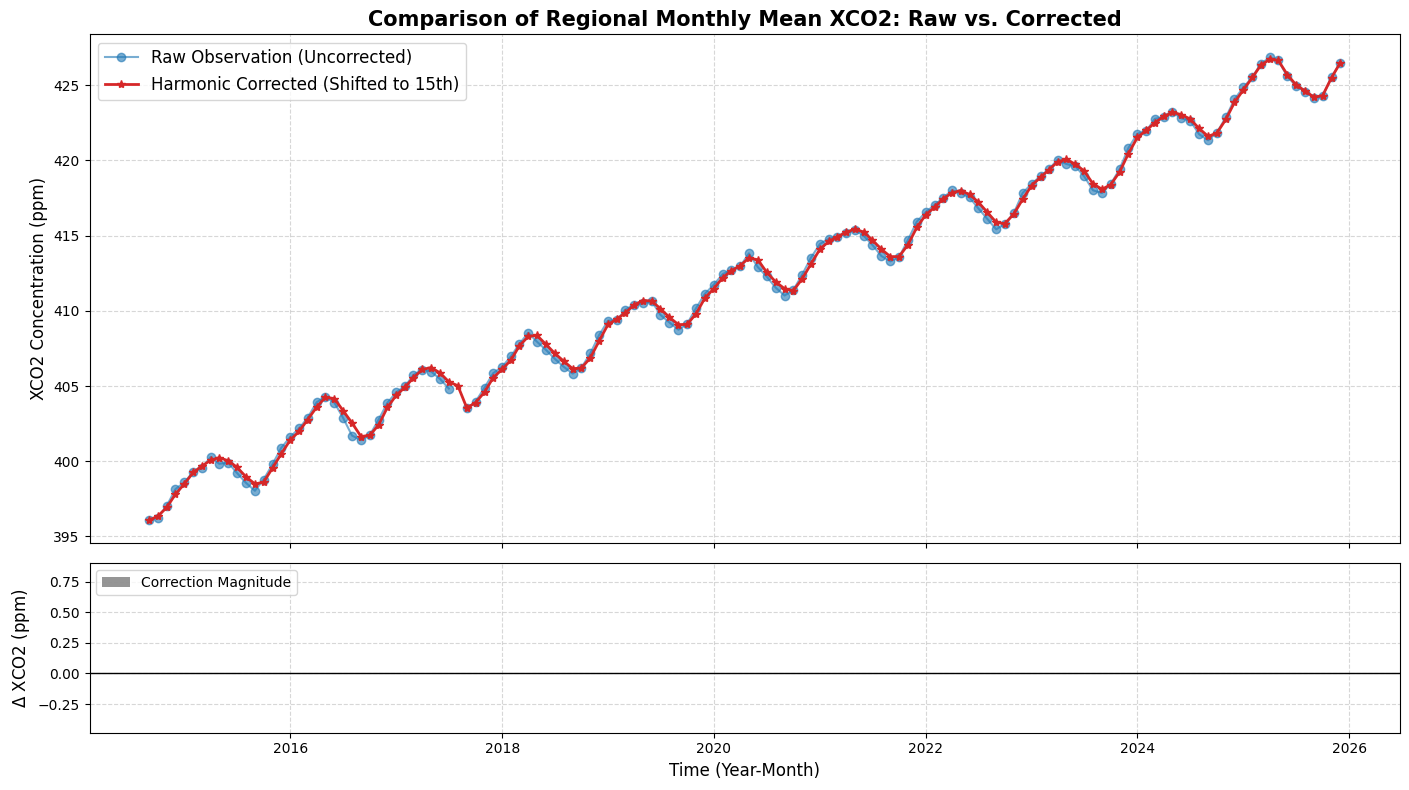

📊 统计摘要：
最大单月订正幅度: 0.839 ppm
平均每月订正幅度: 0.215 ppm


In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

daily_fn= PROJECT_DIR / "step02_grid" / oco2_path
month_fn= daily_fn.parent / daily_fn.name.replace("daily","month")
daily_ds = xr.open_dataset(daily_fn)
raw_month_ds = daily_ds.resample(time='1MS').mean()
ts_raw = raw_month_ds['xco2'].mean(dim=['lat', 'lon'])
month_ds = xr.open_dataset(month_fn)
ts_corrected = month_ds['xco2'].mean(dim=['lat', 'lon'])

ts_diff = ts_corrected - ts_raw

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 8),
                               gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(ts_raw.time, ts_raw.values,
         marker='o', linestyle='-', color='tab:blue', alpha=0.6,
         label='Raw Observation (Uncorrected)')

ax1.plot(ts_corrected.time, ts_corrected.values,
         marker='*', linestyle='-', color='tab:red', linewidth=2,
         label='Harmonic Corrected (Shifted to 15th)')

ax1.set_title('Comparison of Regional Monthly Mean XCO2: Raw vs. Corrected', fontsize=15, fontweight='bold')
ax1.set_ylabel('XCO2 Concentration (ppm)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=12, loc='upper left')

ax2.bar(ts_diff.time, ts_diff.values, width=20, color='dimgray', alpha=0.7, label='Correction Magnitude')
ax2.axhline(0, color='black', linewidth=1) # 0基准线

ax2.set_xlabel('Time (Year-Month)', fontsize=12)
ax2.set_ylabel('$Δ$ XCO2 (ppm)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

max_diff = np.abs(ts_diff).max().values
mean_diff = np.abs(ts_diff).mean().values
print(f"📊 督襣睙督督督督督督督:")
print(f"最大单月膆督督督督: {max_diff:.3f} ppm")
print(f"平均每月膆督督督督: {mean_diff:.3f} ppm")

# 自适应局部时空克里金-数据准备

In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import gc
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import gstools

warnings.filterwarnings("ignore")

# =========================================================
# 1. 路径配置与数据读取 & 裁剪
# =========================================================
print(f"[{time.strftime('%H:%M:%S')}] Step 1: 初始化路径与数据...")
stat_tag = "oco2"  # 可选 "oco2" 或 "oco3"

PROJECT_DIR=Path("/content/drive/MyDrive/东南亚数据集")
STEP03_DIR = PROJECT_DIR / "step03_谐波订正"
STEP04_DIR = PROJECT_DIR / "step04_stk_fill"
OUT_SUBDIR = STEP04_DIR / stat_tag

STEP03_DIR.mkdir(parents=True, exist_ok=True)
STEP04_DIR.mkdir(parents=True, exist_ok=True)
OUT_SUBDIR.mkdir(parents=True, exist_ok=True)

if stat_tag == "oco2":
    xco2_fn = STEP03_DIR / "oco2_xco2_month_201409_202512.nc"
elif stat_tag == "oco3":
    xco2_fn = STEP03_DIR / "oco3_xco2_month_201908_202512.nc"
else:
    raise ValueError("stat_tag must be 'oco2' or 'oco3'")

cams_fn = STEP03_DIR / "cams_xco2_month_2015_2024_resize.nc"

ds_o = xr.open_dataset(xco2_fn).sortby("time")
ds_c = xr.open_dataset(cams_fn, engine="netcdf4").sortby("time")


if ds_c["xco2"].mean().item() < 1.0:
    ds_c["xco2"] = ds_c["xco2"] * 1e6

common_time = np.intersect1d(ds_o.time.values, ds_c.time.values)
if len(common_time) == 0:
    raise ValueError("⚠️ 卫星数据与 CAMS 没有重叠时间段！")

ds_o = ds_o.sel(time=common_time)
ds_c = ds_c.sel(time=common_time)


print(f"[{time.strftime('%H:%M:%S')}] 正在计算并清洗残差场 (物理阈值 ±2.0 ppm)...")
da_res_all_raw = (ds_o["xco2"] - ds_c["xco2"]).astype("float32").load()
res_array_raw = da_res_all_raw.values.copy()

# 仅信任与背景场偏差在 ±5 ppm 以内的观测
mask_valid = (res_array_raw >= -5) & (res_array_raw <= 5)
res_array_cleaned = np.full_like(res_array_raw, np.nan)
res_array_cleaned[mask_valid] = res_array_raw[mask_valid]

da_res_all = da_res_all_raw.copy()
da_res_all.values = res_array_cleaned

num_before = np.sum(~np.isnan(res_array_raw))
num_after = np.sum(~np.isnan(res_array_cleaned))
print(f"✅ 残差清洗完成: 剔除了 {num_before - num_after} 个极端噪声点。")

lat_g = ds_o["lat"].values.astype("float32")
lon_g = ds_o["lon"].values.astype("float32")
unique_times = pd.to_datetime(ds_c.time.values)
months_list = sorted(list(set(unique_times)))
print("残差的实际方差为:", np.nanvar(res_array_cleaned))

[11:32:42] Step 1: 初始化路径与数据...
[11:32:43] 正在计算并清洗残差场 (物理阈值 ±2.0 ppm)...
✅ 残差清洗完成: 剔除了 5677 个极端噪声点。
残差的实际方差为: 1.173412


# 自适应局部时空克里金-关键参数

In [ ]:
# -*- coding: utf-8 -*-
import os
import time
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import gstools as gs
from scipy.spatial import cKDTree
from scipy.ndimage import (
    gaussian_filter,
    distance_transform_edt,
    median_filter,
    label
)
from joblib import Parallel, delayed


months_list = pd.to_datetime(da_res_all.time.values).to_pydatetime()
lon_g = da_res_all.lon.values
lat_g = da_res_all.lat.values

res_array = da_res_all.values.astype(np.float32)
ntime, nlat, nlon = res_array.shape

target_lon_mesh, target_lat_mesh = np.meshgrid(lon_g, lat_g)
target_lon_flat = target_lon_mesh.ravel()
target_lat_flat = target_lat_mesh.ravel()
n_targets = target_lon_flat.size


# =========================================================
# 1. 参数配置
# =========================================================
print(f"[{time.strftime('%H:%M:%S')}] Step 1: 配置最终版时空自适应局部 Ordinary Kriging...")

# ---- 时间窗口 ----
TIME_WIN = 2

# ---- 邻点搜索参数 ----
ADAPTIVE_K = 150
MIN_NEIGHBORS = 10
MAX_NEIGHBORS_USED = 50

# ---- 三维时空联合搜索尺度 ----
SEARCH_LON_SCALE = 2.5
SEARCH_LAT_SCALE = 1.5
SEARCH_TIME_SCALE = 1.4
MAX_ST_SEARCH_RADIUS = 4.5

# ---- 局地自适应变程范围 ----
LEN_X_MIN, LEN_X_MAX = 0.8, 2.5
LEN_T_MIN, LEN_T_MAX = 0.8, 1.8

# ---- 各向异性约束 ----
ANIS_RATIO_XY_MIN = 1.0
ANIS_RATIO_XY_MAX = 2.5

# ---- 变异函数参数 ----
GLOBAL_VAR = 1.28
GLOBAL_NUGGET = 0.35
EXACT_MODE = False

# ---- 邻点质量控制 ----
MIN_UNIQUE_TIMES = 1
MIN_LON_SPREAD = 0.08
MIN_LAT_SPREAD = 0.08

# ---- IDW 兜底 ----
IDW_POWER = 2.0
IDW_MAX_USE = 10

# ---- 残差裁剪和平滑 ----
RES_CLIP_MIN = -1.2
RES_CLIP_MAX = 1.2
SMOOTH_SIGMA = 0.5

# ---- 去小点 / 去碎斑 ----
DESPECKLE_MEDIAN_SIZE = 5
DESPECKLE_PATCH_DIFF = 0.10
DESPECKLE_PATCH_MIN_SIZE = 6

# ---- 低观测月份保护 ----
LOW_OBS_THRESHOLD = 300
VERY_LOW_OBS_THRESHOLD = 100

# ---- 距离衰减 ----
USE_DISTANCE_DECAY = True
DECAY_SCALE = 1.8

# ---- 观测-插值平滑融合 ----
BLEND_TRANS_PIXELS = 3.0
BLEND_OBS_WEIGHT_MIN = 0.20

# ---- 并行 ----
N_JOBS = max(1, (os.cpu_count() or 4) - 2)


# =========================================================
# 2. 工具函数
# =========================================================
def robust_percentile_span(arr, q=85, fallback=np.nan):
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return fallback
    return np.percentile(arr, q)


def build_local_model(cond_lon, cond_lat, cond_t):
    """
    根据局部邻点分布，自适应构建局部时空变异函数
    """
    lon_center = np.mean(cond_lon)
    lat_center = np.mean(cond_lat)

    dx = cond_lon - lon_center
    dy = cond_lat - lat_center
    spatial_dist = np.sqrt(dx**2 + dy**2)

    local_span_xy = robust_percentile_span(spatial_dist, q=85, fallback=1.2)
    if not np.isfinite(local_span_xy):
        local_span_xy = 1.2

    len_x = np.clip(local_span_xy * 1.8, LEN_X_MIN, LEN_X_MAX)

    lon_spread = np.nanpercentile(cond_lon, 90) - np.nanpercentile(cond_lon, 10)
    lat_spread = np.nanpercentile(cond_lat, 90) - np.nanpercentile(cond_lat, 10)

    if lat_spread < 1e-6:
        xy_ratio = ANIS_RATIO_XY_MAX
    else:
        xy_ratio = np.clip(lon_spread / lat_spread, ANIS_RATIO_XY_MIN, ANIS_RATIO_XY_MAX)

    ratio_y = 1.0 / xy_ratio

    t_center = np.mean(cond_t)
    dt = np.abs(cond_t - t_center)
    local_span_t = robust_percentile_span(dt, q=80, fallback=1.0)
    if not np.isfinite(local_span_t):
        local_span_t = 1.0

    len_t = np.clip(local_span_t * 1.6 + 0.5, LEN_T_MIN, LEN_T_MAX)
    ratio_t = len_t / len_x

    model = gs.Exponential(
        spatial_dim=2,
        temporal=True,
        len_scale=len_x,
        anis=[ratio_y, ratio_t],
        var=GLOBAL_VAR,
        nugget=GLOBAL_NUGGET
    )
    return model


def screen_neighbors(cond_lon, cond_lat, cond_t, cond_val, st_dists):
    """
    邻点筛选与质量控制
    """
    n_all = len(cond_val)
    if n_all < MIN_NEIGHBORS:
        return None

    order = np.argsort(st_dists)
    cond_lon = cond_lon[order]
    cond_lat = cond_lat[order]
    cond_t = cond_t[order]
    cond_val = cond_val[order]
    st_dists = st_dists[order]

    keep = min(MAX_NEIGHBORS_USED, n_all)
    cond_lon = cond_lon[:keep]
    cond_lat = cond_lat[:keep]
    cond_t = cond_t[:keep]
    cond_val = cond_val[:keep]
    st_dists = st_dists[:keep]

    unique_times = np.unique(cond_t)
    if len(unique_times) < MIN_UNIQUE_TIMES:
        return None

    lon_spread = np.nanpercentile(cond_lon, 90) - np.nanpercentile(cond_lon, 10)
    lat_spread = np.nanpercentile(cond_lat, 90) - np.nanpercentile(cond_lat, 10)

    if (lon_spread < MIN_LON_SPREAD) or (lat_spread < MIN_LAT_SPREAD):
        return None

    return cond_lon, cond_lat, cond_t, cond_val, st_dists


def idw_fallback(cond_val, st_dists, power=2.0, max_use=12):
    """
    STK失败时的IDW残差兜底
    """
    cond_val = np.asarray(cond_val, dtype=float)
    st_dists = np.asarray(st_dists, dtype=float)

    good = np.isfinite(cond_val) & np.isfinite(st_dists)
    cond_val = cond_val[good]
    st_dists = st_dists[good]

    if cond_val.size == 0:
        return 0.0

    order = np.argsort(st_dists)
    cond_val = cond_val[order][:max_use]
    st_dists = st_dists[order][:max_use]

    if cond_val.size == 0:
        return 0.0

    if np.min(st_dists) < 1e-6:
        return float(cond_val[np.argmin(st_dists)])

    weights = 1.0 / np.maximum(st_dists, 1e-6) ** power
    wsum = np.sum(weights)

    if wsum <= 0 or not np.isfinite(wsum):
        return 0.0

    pred = np.sum(weights * cond_val) / wsum
    return float(pred)


def remove_small_patch_by_label(arr, diff_threshold=0.18, min_size=5):
    """
    清理相对局地背景偏差明显、但面积很小的孤立斑块
    """
    arr = np.asarray(arr, dtype=np.float32)
    out = arr.copy()

    bg = gaussian_filter(arr, sigma=1.2)

    # 正异常小斑块
    pos_mask = (arr - bg) > diff_threshold
    lab_pos, n_pos = label(pos_mask)

    for k in range(1, n_pos + 1):
        region = (lab_pos == k)
        if region.sum() < min_size:
            out[region] = bg[region]

    # 负异常小斑块
    neg_mask = (bg - arr) > diff_threshold
    lab_neg, n_neg = label(neg_mask)

    for k in range(1, n_neg + 1):
        region = (lab_neg == k)
        if region.sum() < min_size:
            out[region] = bg[region]

    return out.astype(np.float32)


def despeckle_residual_field(arr,
                             median_size=3,
                             patch_diff_threshold=0.18,
                             patch_min_size=6):
    """
    去小点/去碎斑：
    1) 中值滤波去椒盐点
    2) 小斑块面积过滤
    """
    arr = np.asarray(arr, dtype=np.float32)

    arr_med = median_filter(arr, size=median_size, mode="nearest")

    arr_clean = remove_small_patch_by_label(
        arr_med,
        diff_threshold=patch_diff_threshold,
        min_size=patch_min_size
    )

    return arr_clean.astype(np.float32)


def blend_observation_and_interp(obs_residual, interp_residual,
                                 obs_mask,
                                 trans_pixels=3.0,
                                 obs_weight_min=0.15):
    """
    将原始观测残差与插值残差做平滑融合，避免硬拼接
    """
    dist_inside = distance_transform_edt(obs_mask)

    obs_weight = 1.0 - np.exp(-(dist_inside / max(trans_pixels, 1e-6)) ** 2)
    obs_weight = obs_weight * (1.0 - obs_weight_min) + obs_weight_min
    obs_weight[~obs_mask] = 0.0

    blended = interp_residual.copy()
    blended[obs_mask] = (
        obs_weight[obs_mask] * obs_residual[obs_mask]
        + (1.0 - obs_weight[obs_mask]) * interp_residual[obs_mask]
    )

    return blended.astype(np.float32)


# =========================================================
# 3. 单像元预测函数
# =========================================================
def _predict_single_pixel(i, tgt_lon, tgt_lat, tgt_t,
                          neigh_idx, neigh_dist, valid_len,
                          v_lon, v_lat, v_t, v_vals,
                          obs_mask_flat_for_month):
    """
    单像元局部时空 Ordinary Kriging
    优先 STK，失败则 IDW，最后回 0 残差
    """
    if obs_mask_flat_for_month[i]:
        r, c = divmod(i, nlon)
        return i, res_array[tgt_t, r, c]

    valid_mask = neigh_idx < valid_len
    if valid_mask.sum() == 0:
        return i, 0.0

    idx = neigh_idx[valid_mask]
    st_d = neigh_dist[valid_mask]

    cond_lon = v_lon[idx]
    cond_lat = v_lat[idx]
    cond_t = v_t[idx].astype(float)
    cond_val = v_vals[idx]

    screened = screen_neighbors(cond_lon, cond_lat, cond_t, cond_val, st_d)

    if screened is None:
        pred_idw = idw_fallback(cond_val, st_d, power=IDW_POWER, max_use=IDW_MAX_USE)
        return i, np.float32(pred_idw)

    cond_lon, cond_lat, cond_t, cond_val, st_d = screened

    try:
        model = build_local_model(cond_lon, cond_lat, cond_t)

        krig = gs.krige.Ordinary(
            model,
            cond_pos=[cond_lon, cond_lat, cond_t],
            cond_val=cond_val,
            exact=EXACT_MODE
        )

        pred, _ = krig(([tgt_lon], [tgt_lat], [float(tgt_t)]))
        pred_val = float(pred[0])

        if np.isfinite(pred_val):
            return i, np.float32(pred_val)
        else:
            pred_idw = idw_fallback(cond_val, st_d, power=IDW_POWER, max_use=IDW_MAX_USE)
            return i, np.float32(pred_idw)

    except Exception:
        pred_idw = idw_fallback(cond_val, st_d, power=IDW_POWER, max_use=IDW_MAX_USE)
        return i, np.float32(pred_idw)


# =========================================================
# 4. 单个月份重建
# =========================================================
def krige_for_month(t_idx):
    """
    对单个月份执行最终版局部时空自适应 Ordinary Kriging
    """
    print(f"[{time.strftime('%H:%M:%S')}] 月份索引 {t_idx+1}/{ntime} 开始...")

    t_start = max(0, t_idx - TIME_WIN)
    t_end = min(ntime - 1, t_idx + TIME_WIN)

    window_data = res_array[t_start:t_end + 1, :, :]
    valid_idx = np.where(~np.isnan(window_data))

    if len(valid_idx[0]) < MIN_NEIGHBORS:
        print("  ⚠️ 时间窗内有效点过少，直接返回 0 残差场")
        return t_idx, np.zeros((nlat, nlon), dtype=np.float32)

    valid_t = valid_idx[0] + t_start
    valid_y = valid_idx[1]
    valid_x = valid_idx[2]

    v_lon = lon_g[valid_x].astype(np.float32)
    v_lat = lat_g[valid_y].astype(np.float32)
    v_t = valid_t.astype(np.float32)
    v_vals = window_data[valid_idx].astype(np.float32)

    valid_len = len(v_vals)

    # ---- 构建三维时空 KDTree ----
    tree_coords = np.column_stack([
        v_lon / SEARCH_LON_SCALE,
        v_lat / SEARCH_LAT_SCALE,
        v_t / SEARCH_TIME_SCALE
    ]).astype(np.float32)

    tree = cKDTree(tree_coords)

    target_coords = np.column_stack([
        target_lon_flat / SEARCH_LON_SCALE,
        target_lat_flat / SEARCH_LAT_SCALE,
        np.full(n_targets, t_idx / SEARCH_TIME_SCALE, dtype=np.float32)
    ])

    dists, indices = tree.query(
        target_coords,
        k=ADAPTIVE_K,
        distance_upper_bound=MAX_ST_SEARCH_RADIUS
    )

    obs_mask_flat = (~np.isnan(res_array[t_idx])).ravel()
    obs_count_this_month = int(np.isfinite(res_array[t_idx]).sum())
    print(f"  本月原始观测点数: {obs_count_this_month}")

    # ---- 并行逐像元预测 ----
    pixel_results = Parallel(n_jobs=N_JOBS, batch_size='auto', backend='loky')(
        delayed(_predict_single_pixel)(
            i=i,
            tgt_lon=target_lon_flat[i],
            tgt_lat=target_lat_flat[i],
            tgt_t=t_idx,
            neigh_idx=indices[i],
            neigh_dist=dists[i],
            valid_len=valid_len,
            v_lon=v_lon,
            v_lat=v_lat,
            v_t=v_t,
            v_vals=v_vals,
            obs_mask_flat_for_month=obs_mask_flat
        )
        for i in range(n_targets)
    )

    # ---- 回填到二维网格 ----
    pred_month = np.full((nlat, nlon), np.nan, dtype=np.float32)
    for i, val in pixel_results:
        r, c = divmod(i, nlon)
        pred_month[r, c] = val

    pred_month = np.where(np.isfinite(pred_month), pred_month, 0.0).astype(np.float32)

    # ---- 残差裁剪 ----
    pred_month = np.clip(pred_month, RES_CLIP_MIN, RES_CLIP_MAX).astype(np.float32)

    # ---- 轻微高斯平滑 ----
    pred_month_smooth = gaussian_filter(pred_month, sigma=SMOOTH_SIGMA).astype(np.float32)

    # ---- 去小点 / 去碎斑 ----
    pred_month_smooth = despeckle_residual_field(
        pred_month_smooth,
        median_size=DESPECKLE_MEDIAN_SIZE,
        patch_diff_threshold=DESPECKLE_PATCH_DIFF,
        patch_min_size=DESPECKLE_PATCH_MIN_SIZE
    ).astype(np.float32)

    # ---- 距离衰减：离观测轨道越远，残差越弱 ----
    if USE_DISTANCE_DECAY:
        nearest_dist, _ = tree.query(target_coords, k=1)
        decay = np.exp(-(nearest_dist / DECAY_SCALE) ** 2).reshape(nlat, nlon).astype(np.float32)
        pred_month_smooth = pred_month_smooth * decay

    # ---- 低观测月份保护 ----
    if obs_count_this_month < VERY_LOW_OBS_THRESHOLD:
        print("  ⚠️ 极稀疏月份：残差场仅保留 10%")
        pred_month_smooth = pred_month_smooth * 0.1
    elif obs_count_this_month < LOW_OBS_THRESHOLD:
        shrink = obs_count_this_month / LOW_OBS_THRESHOLD
        print(f"  ⚠️ 稀疏月份：残差场按比例缩减，shrink={shrink:.2f}")
        pred_month_smooth = pred_month_smooth * shrink

    # ---- 原始观测残差先裁剪，再与插值残差平滑融合 ----
    original_obs = res_array[t_idx].copy()
    original_obs = np.where(
        np.isfinite(original_obs),
        np.clip(original_obs, -1.0, 1.0),
        np.nan
    ).astype(np.float32)

    obs_mask_2d = ~np.isnan(original_obs)

    pred_month_blend = blend_observation_and_interp(
        obs_residual=original_obs,
        interp_residual=pred_month_smooth,
        obs_mask=obs_mask_2d,
        trans_pixels=BLEND_TRANS_PIXELS,
        obs_weight_min=BLEND_OBS_WEIGHT_MIN
    )

    valid_ratio = np.isfinite(pred_month_blend).sum() / pred_month_blend.size * 100
    print(f"[{time.strftime('%H:%M:%S')}] 月份索引 {t_idx+1}/{ntime} 完成，覆盖率 {valid_ratio:.1f}%")

    return t_idx, pred_month_blend.astype(np.float32)

[11:32:57] Step 1: 配置最终版时空自适应局部 Ordinary Kriging...


# 自适应局部时空克里金-实现

In [ ]:
#逐月插值
import os
import time
import numpy as np
import xarray as xr
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm  # 🌟 新增：导入 tqdm 自动匹配 Notebook/Console 进度条

PROJECT_DIR=Path("/content/drive/MyDrive/东南亚数据集")
OUT_PATH =PROJECT_DIR / "step04_stk_fill" / stat_tag
os.makedirs(OUT_PATH, exist_ok=True)

print(f"\n{'='*60}")
print(f"🚀 开始全时间序列 (逐月) STK 插值并导出 NetCDF")
print(f"📂 输出目录: {os.path.abspath(OUT_PATH)}")
print(f"{'='*60}")

total_months = len(months_list)
pbar = tqdm(range(total_months), desc="STK 重建进度", unit="月")

for target_t_idx in pbar:
    target_time = months_list[target_t_idx]
    target_year = target_time.year
    target_month = target_time.month
    out_filename = f"XCO2_STK_Yunnan_{target_year}{target_month:02d}.nc"
    out_path = OUT_PATH / out_filename

    if out_path.exists():
        continue

    pbar.set_postfix({"当前处理": f"{target_year}-{target_month:02d}"})

    start_time = time.time()
    _, pred_month_target = krige_for_month(target_t_idx)

    cams_bg = ds_c["xco2"].values[target_t_idx].astype(np.float32)
    filled_xco2_raw = cams_bg + pred_month_target

    FINAL_SMOOTH_SIGMA = 0.6
    filled_xco2 = gaussian_filter(filled_xco2_raw, sigma=FINAL_SMOOTH_SIGMA).astype(np.float32)

    ds_out = xr.Dataset(
        {
            "xco2": (["time", "lat", "lon"], filled_xco2[np.newaxis, :, :],
                     {"units": "ppm", "long_name": "Reconstructed XCO2 (STK + CAMS)"})
        },
        coords={
            "time": [target_time],
            "lat": (["lat"], lat_g, {"units": "degrees_north"}),
            "lon": (["lon"], lon_g, {"units": "degrees_east"})
        },
        attrs={
            "description": "High-resolution XCO2 reconstructed using STK and CAMS background.",
            "creation_date": time.strftime('%Y-%m-%d %H:%M:%S')
        }
    )
    ds_out.to_netcdf(out_path)
    ds_out.close()
    cost_time = time.time() - start_time
    tqdm.write(f"✅ {target_year}-{target_month:02d} 完成！耗时: {cost_time:.2f} 秒，已保存: {out_filename}")

print(f"\n🎉 所有 {total_months} 个月的插值和导出任务已全部完成！")


🚀 开始全时间序列 (逐月) STK 插值并导出 NetCDF
📂 输出目录: /content/drive/MyDrive/东南亚数据集/step04_stk_fill/oco2


STK 重建进度:   0%|          | 0/130 [00:00<?, ?月/s]

[11:40:32] 月份索引 52/130 开始...
  本月原始观测点数: 24187
[11:43:21] 月份索引 52/130 完成，覆盖率 100.0%
✅ 2019-01 完成！耗时: 169.24 秒，已保存: XCO2_STK_Yunnan_201901.nc
[11:43:21] 月份索引 53/130 开始...
  本月原始观测点数: 32633
[11:46:06] 月份索引 53/130 完成，覆盖率 100.0%
✅ 2019-02 完成！耗时: 164.99 秒，已保存: XCO2_STK_Yunnan_201902.nc
[11:46:06] 月份索引 54/130 开始...
  本月原始观测点数: 29622
[11:48:51] 月份索引 54/130 完成，覆盖率 100.0%
✅ 2019-03 完成！耗时: 165.45 秒，已保存: XCO2_STK_Yunnan_201903.nc
[11:48:51] 月份索引 55/130 开始...
  本月原始观测点数: 28398
[11:51:37] 月份索引 55/130 完成，覆盖率 100.0%
✅ 2019-04 完成！耗时: 166.00 秒，已保存: XCO2_STK_Yunnan_201904.nc
[11:51:37] 月份索引 56/130 开始...
  本月原始观测点数: 29878
[11:54:29] 月份索引 56/130 完成，覆盖率 100.0%
✅ 2019-05 完成！耗时: 172.02 秒，已保存: XCO2_STK_Yunnan_201905.nc
[11:54:29] 月份索引 57/130 开始...
  本月原始观测点数: 23565
[11:57:17] 月份索引 57/130 完成，覆盖率 100.0%
✅ 2019-06 完成！耗时: 168.13 秒，已保存: XCO2_STK_Yunnan_201906.nc
[11:57:17] 月份索引 58/130 开始...
  本月原始观测点数: 21934
[12:00:07] 月份索引 58/130 完成，覆盖率 100.0%
✅ 2019-07 完成！耗时: 169.29 秒，已保存: XCO2_STK_Yunnan_201907.nc
[12:00:07] 月份

In [ ]:
# @title
#合并
import os
import xarray as xr
from pathlib import Path

PROJECT_DIR=Path("/content/drive/MyDrive/东南亚数据集")
STEP04_DIR = PROJECT_DIR / "step04_stk_fill"
stat_tag = "oco2"

OUT_SUBDIR = STEP04_DIR / stat_tag

print(f"\n📦 正在进行最终文件合并...")

files_to_merge = sorted(OUT_SUBDIR.glob(f"XCO2_STK_Yunnan_*.nc"))

if not files_to_merge:
    raise FileNotFoundError(f"未找到任何要合并的年度文件在: {OUT_SUBDIR}")

start_year = int(str(files_to_merge[0].stem).split('_')[-1][:4])
end_year = int(str(files_to_merge[-1].stem).split('_')[-1][:4])

final_merged_file = STEP04_DIR / f"{stat_tag}_xco2_month_{start_year}_{end_year}_stk_cn.nc"

if final_merged_file.exists():
    print(f"✨ 最终合并文件已存在，跳过合并步骤: {final_merged_file}")
else:
    print(f"找到 {len(files_to_merge)} 个文件准备合并...")
    ds_final = xr.open_mfdataset(files_to_merge, combine="nested", concat_dim="time", join="override")
    ds_final = ds_final.sortby("time")
    ds_final.to_netcdf(
        final_merged_file,
        encoding={
            "xco2": {"zlib": True, "complevel": 1}
        }
    )

    print(f"✨ 任务圆满完成！最终合并文件：{final_merged_file}")
    print(f"数据维度: {dict(ds_final.sizes)}")
    ds_final.close()



📦 正在进行最终文件合并...
找到 130 个文件准备合并...
✨ 任务圆满完成！最终合并文件：/content/drive/MyDrive/东南亚数据集/step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc
数据维度: {'time': 130, 'lat': 491, 'lon': 611}


# 时空特征分析

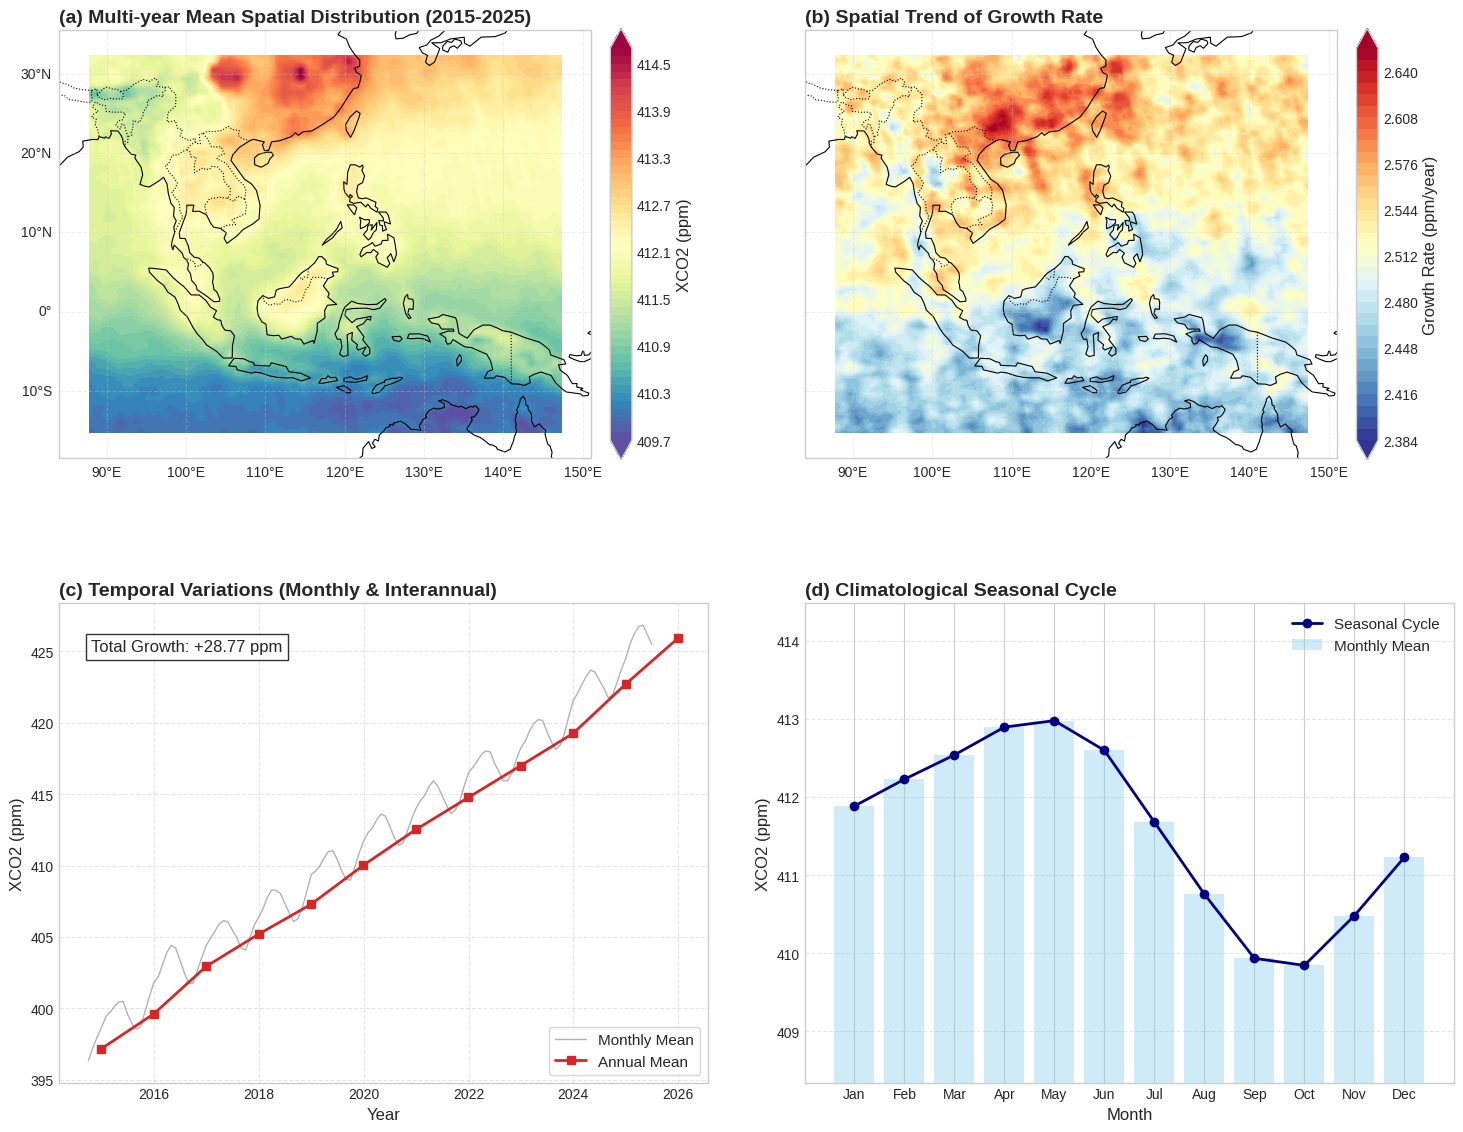

In [ ]:
# @title
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.ticker as mticker
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

nc_path= STEP04_DIR / f"{stat_tag}_xco2_month_{start_year}_{end_year}_stk_cn.nc"
ds = xr.open_dataset(nc_path)
var_name = list(ds.data_vars)[0]

name_dict = {}
for coord in ds.coords:
    c_low = coord.lower()
    if c_low in ['lat', 'latitude', 'lats']:
        name_dict[coord] = 'lat'
    elif c_low in ['lon', 'longitude', 'lons']:
        name_dict[coord] = 'lon'

if name_dict:
    ds = ds.rename(name_dict)

if 'lat' in ds.data_vars:
    ds = ds.set_coords(['lat', 'lon'])

var_name = list(ds.data_vars)[0]
da = ds[var_name]


da = ds[var_name]
if da.isnull().sum() > 0:
    da = da.interpolate_na(dim='lon', method='linear').interpolate_na(dim='lat', method='linear')

mean_map = da.mean(dim='time')
years_float = [pd.Timestamp(t).year + (pd.Timestamp(t).month-1)/12.0 for t in da.time.values]
da_trend = da.assign_coords(time=years_float)
poly = da_trend.polyfit(dim='time', deg=1)
slope_map = poly['polyfit_coefficients'].sel(degree=1) # 单位: ppm/year


ts_monthly = da.mean(dim=['lat', 'lon'])
ts_yearly = ts_monthly.resample(time='1Y').mean()

# 4. 季节性循环 (Line) - 去趋势
# 先计算线性趋势
slope_t, intercept_t, _, _, _ = stats.linregress(np.arange(len(ts_monthly)), ts_monthly.values)
trend_line = intercept_t + slope_t * np.arange(len(ts_monthly))
ts_detrended = ts_monthly - trend_line
seasonal_cycle = ts_detrended.groupby('time.month').mean() + ts_monthly.mean() # 加回均值保持数值量级，或直接用 Anomaly

# ================= 2. 绘图 (2x2 面板) =================
fig = plt.figure(figsize=(18, 14))
# 调整子图间距
plt.subplots_adjust(wspace=0.15, hspace=0.25)

# ---------------- 子图1: 多年平均空间分布 (Map) ----------------
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
im1 = ax1.contourf(
    mean_map.lon, mean_map.lat, mean_map,
    transform=ccrs.PlateCarree(),
    cmap='Spectral_r', levels=60, extend='both'
)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
# 颜色条
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.9, pad=0.03)
cbar1.set_label('XCO2 (ppm)', fontsize=12)
ax1.set_title('(a) Multi-year Mean Spatial Distribution (2015-2025)', fontsize=14, loc='left', fontweight='bold')
# 经纬度标签
gl1 = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
gl1.top_labels = False
gl1.right_labels = False

# ---------------- 子图2: 空间增长率趋势 (Map) ----------------
ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
im2 = ax2.contourf(
    slope_map.lon, slope_map.lat, slope_map,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r', levels=40, extend='both' # 红=增长快
)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.9, pad=0.03)
cbar2.set_label('Growth Rate (ppm/year)', fontsize=12)
ax2.set_title('(b) Spatial Trend of Growth Rate', fontsize=14, loc='left', fontweight='bold')
gl2 = ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
gl2.top_labels = False
gl2.right_labels = False
gl2.left_labels = False # 省略中间的纬度标

# ---------------- 子图3: 逐年逐月变化曲线 (Time Series) ----------------
ax3 = fig.add_subplot(2, 2, 3)
# 绘制逐月曲线 (灰色细线)
ax3.plot(ts_monthly.time, ts_monthly, color='gray', alpha=0.6, linewidth=1, label='Monthly Mean')
# 绘制逐年均值 (红色方块线) - 代表年际变化
ax3.plot(ts_yearly.time, ts_yearly, 's-', color='#d62728', linewidth=2, label='Annual Mean')

# 计算总体增长率用于标注
total_growth = (ts_yearly[-1] - ts_yearly[0]).values
ax3.text(0.05, 0.9, f'Total Growth: +{total_growth:.2f} ppm', transform=ax3.transAxes,
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

ax3.set_ylabel('XCO2 (ppm)', fontsize=12)
ax3.set_xlabel('Year', fontsize=12)
ax3.legend(fontsize=11, frameon=True)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_title('(c) Temporal Variations (Monthly & Interannual)', fontsize=14, loc='left', fontweight='bold')

# ---------------- 子图4: 多年月均值 / 季节性 (Seasonal) ----------------
ax4 = fig.add_subplot(2, 2, 4)
months = np.arange(1, 13)
# 绘制柱状图背景
ax4.bar(months, seasonal_cycle, color='skyblue', alpha=0.4, label='Monthly Mean')
# 绘制平滑曲线
ax4.plot(months, seasonal_cycle, 'o-', color='navy', linewidth=2, label='Seasonal Cycle')

# 设置X轴为月份名
ax4.set_xticks(months)
ax4.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax4.set_ylabel('XCO2 (ppm)', fontsize=12)
ax4.set_xlabel('Month', fontsize=12)

y_min, y_max = seasonal_cycle.min(), seasonal_cycle.max()
ax4.set_ylim(y_min - 1.5, y_max + 1.5)

ax4.legend(fontsize=11)
ax4.grid(True, axis='y', linestyle='--', alpha=0.5)
ax4.set_title('(d) Climatological Seasonal Cycle', fontsize=14, loc='left', fontweight='bold')

#png_fn=os.path.join(PROJECT_DIR,"结果与分析","空间分布图","xco2时空特征2015-2025.png")
#plt.savefig(png_fn, dpi=300, bbox_inches='tight')
plt.show()

# 交叉验证


🚀 开始处理目标: 2024年3月
[16:12:33] 🎯 找到测试目标: 2024-03 (时间索引: 113)
[16:12:33] 🎲 数据集划分完成: 本月共 21887 个有效观测点。
   -> 参与插值 (90%): 19699 个点
   -> 独立验证 (10%): 2188 个点 (这些点对插值算法完全隐身)
[16:12:33] 开始计算 2024-03 的全场 STK 重建 (基于 90% 数据)...
[16:12:33] 月份索引 114/130 开始...
  本月原始观测点数: 19699
[16:15:31] 月份索引 114/130 完成，覆盖率 100.0%
[16:15:31] 正在对最终 XCO2 场进行高斯平滑 (sigma=0.6)...
[16:15:31] ✅ 2024-03 重建与平滑完成！耗时: 177.53 秒
[16:15:31] 正在生成空间分布与独立验证精度图...


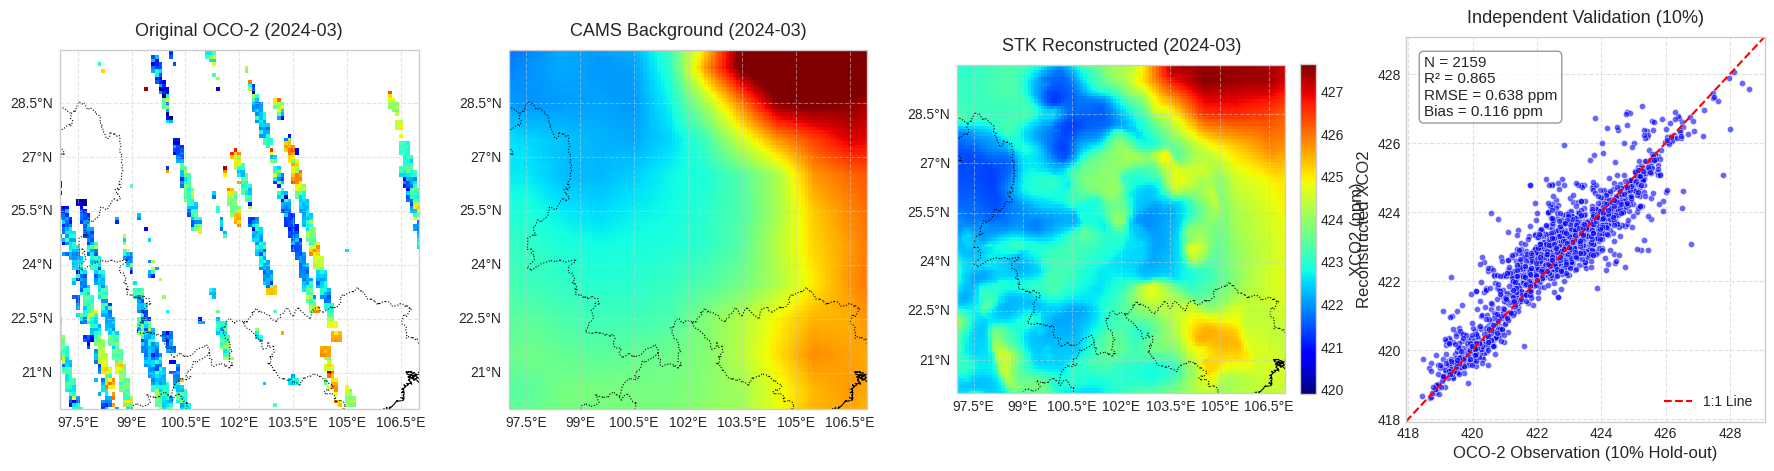

In [ ]:
extent= [90,145,-10,30]
date_list = [(2024, 3), (2024, 6), (2024, 9), (2024, 12)]
date_list = [(2024, 3)]
for target_year, target_month in date_list:
    print(f"\n{'='*60}")
    print(f"🚀 开始处理目标: {target_year}年{target_month}月")
    print(f"{'='*60}")

    target_indices = [
        i for i, d in enumerate(months_list)
        if d.year == target_year and d.month == target_month
    ]

    if not target_indices:
        print(f"⚠️ 跳过：在数据集中没有找到 {target_year}年{target_month}月 的数据！")
        continue

    target_t_idx = target_indices[0]
    target_time = months_list[target_t_idx]

    print(f"[{time.strftime('%H:%M:%S')}] 🎯 找到测试目标: {target_time.strftime('%Y-%m')} (时间索引: {target_t_idx})")

    # ---------------------------------------------------------
    # 🌟 新增核心逻辑：90% 训练与 10% 验证划分
    # ---------------------------------------------------------
    # 1. 备份当月的原始残差，用于后续恢复和提取验证集真实值
    original_res_this_month = res_array[target_t_idx].copy()
    valid_coords = np.argwhere(~np.isnan(original_res_this_month))
    n_valid = len(valid_coords)

    # 2. 随机打乱并划分 90% / 10%
    np.random.seed(42)  # 固定随机种子，保证每次运行结果可复现，便于调参
    shuffle_idx = np.random.permutation(n_valid)
    n_val = int(n_valid * 0.1)  # 10% 用于独立验证

    val_idx = shuffle_idx[:n_val]
    train_idx = shuffle_idx[n_val:]

    val_coords = valid_coords[val_idx]
    train_coords = valid_coords[train_idx]

    print(f"[{time.strftime('%H:%M:%S')}] 🎲 数据集划分完成: 本月共 {n_valid} 个有效观测点。")
    print(f"   -> 参与插值 (90%): {len(train_idx)} 个点")
    print(f"   -> 独立验证 (10%): {len(val_idx)} 个点 (这些点对插值算法完全隐身)")

    # 3. 在全局 res_array 中“挖空”这 10% 的验证集
    # 这样 krige_for_month 读取数据时，就不会使用这 10% 的信息
    for r, c in val_coords:
        res_array[target_t_idx, r, c] = np.nan


    # =========================================================
    # 6. 执行单月重建与最终平滑
    # =========================================================
    print(f"[{time.strftime('%H:%M:%S')}] 开始计算 {target_time.strftime('%Y-%m')} 的全场 STK 重建 (基于 90% 数据)...")
    start_time = time.time()

    _, pred_month_target = krige_for_month(target_t_idx)

    # 🌟 重建完成后，把 10% 的数据还原回全局变量，以免影响其他月份的时空插值
    res_array[target_t_idx] = original_res_this_month

    # 残差 + CAMS 背景场 = 最终初步 XCO2
    cams_bg = ds_c["xco2"].values[target_t_idx].astype(np.float32)
    filled_xco2_raw = cams_bg + pred_month_target

    # 对最终结果进行轻度平滑
    FINAL_SMOOTH_SIGMA = 0.6
    print(f"[{time.strftime('%H:%M:%S')}] 正在对最终 XCO2 场进行高斯平滑 (sigma={FINAL_SMOOTH_SIGMA})...")
    filled_xco2 = gaussian_filter(filled_xco2_raw, sigma=FINAL_SMOOTH_SIGMA).astype(np.float32)

    cost_time = time.time() - start_time
    print(f"[{time.strftime('%H:%M:%S')}] ✅ {target_time.strftime('%Y-%m')} 重建与平滑完成！耗时: {cost_time:.2f} 秒")


    # =========================================================
    # 7. 可视化：原始 vs 背景 vs 重建后 + 10% 独立验证散点图
    # =========================================================
    print(f"[{time.strftime('%H:%M:%S')}] 正在生成空间分布与独立验证精度图...")

    # 获取本月的完整原始 XCO2（包含那 10% 没参与插值的点）
    original_xco2 = ds_o["xco2"].values[target_t_idx].astype(np.float32)

    fig = plt.figure(figsize=(22, 5))
    plt.subplots_adjust(wspace=0.25)

    # 依次添加带有地理投影的子图 (1, 2, 3)
    ax1 = fig.add_subplot(1, 4, 1, projection=ccrs.PlateCarree())
    ax2 = fig.add_subplot(1, 4, 2, projection=ccrs.PlateCarree())
    ax3 = fig.add_subplot(1, 4, 3, projection=ccrs.PlateCarree())
    map_axes = [ax1, ax2, ax3]

    # 添加普通的二维散点图 (用于 10% 验证)
    ax4 = fig.add_subplot(1, 4, 4)

    titles = [
        f"Original OCO-2 ({target_time.strftime('%Y-%m')})",
        f"CAMS Background ({target_time.strftime('%Y-%m')})",
        f"STK Reconstructed ({target_time.strftime('%Y-%m')})"
    ]
    data_list = [original_xco2, cams_bg, filled_xco2]

    vmin = np.nanpercentile(cams_bg, 1)
    vmax = np.nanpercentile(cams_bg, 99)

    # ---- 绘制前三个地图 ----
    for i, ax in enumerate(map_axes):
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)

        im = ax.pcolormesh(
            lon_g, lat_g, data_list[i],
            transform=ccrs.PlateCarree(),
            cmap='jet',
            vmin=vmin, vmax=vmax,
            shading='auto'
        )

        ax.set_title(titles[i], fontsize=13, pad=10)
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False

    cbar = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
    cbar.set_label('XCO2 (ppm)', fontsize=12)

    # ---- 绘制第四个子图：10% 独立验证散点图 ----
    if len(val_coords) > 0:
        # 🌟 核心：只提取那 10% 坐标处的真实观测值和重建预测值
        val_rows, val_cols = val_coords[:, 0], val_coords[:, 1]
        obs_vals = original_xco2[val_rows, val_cols]
        rec_vals = filled_xco2[val_rows, val_cols]

        # 清除可能的 NaN (虽然通常 val_coords 里都是有效点)
        valid_mask = ~np.isnan(obs_vals) & ~np.isnan(rec_vals)
        obs_vals = obs_vals[valid_mask]
        rec_vals = rec_vals[valid_mask]

        # 计算评估指标
        rmse = np.sqrt(np.mean((rec_vals - obs_vals)**2))
        bias = np.mean(rec_vals - obs_vals)
        corr = np.corrcoef(obs_vals, rec_vals)[0, 1]
        r2 = corr**2 if not np.isnan(corr) else 0

        # 绘制散点
        ax4.scatter(obs_vals, rec_vals, c='blue', alpha=0.6, s=20, edgecolor='white', linewidth=0.5)

        # 绘制 1:1 参考线
        min_v = min(obs_vals.min(), rec_vals.min()) - 0.5
        max_v = max(obs_vals.max(), rec_vals.max()) + 0.5
        ax4.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='1:1 Line')

        ax4.set_xlim([min_v, max_v])
        ax4.set_ylim([min_v, max_v])
        ax4.set_xlabel("OCO-2 Observation (10% Hold-out)", fontsize=12)
        ax4.set_ylabel("Reconstructed XCO2", fontsize=12)
        ax4.set_title("Independent Validation (10%)", fontsize=13, pad=10)

        # 指标文本框
        textstr = '\n'.join((
            f'N = {len(obs_vals)}',
            f'R² = {r2:.3f}',
            f'RMSE = {rmse:.3f} ppm',
            f'Bias = {bias:.3f} ppm'
        ))
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=11,
                verticalalignment='top', bbox=props)

        ax4.legend(loc='lower right')
        ax4.grid(True, linestyle='--', alpha=0.6)
    else:
        ax4.set_title("Independent Validation (10%)", fontsize=13, pad=10)
        ax4.text(0.5, 0.5, "No validation data", ha='center', va='center', fontsize=12)

    plt.show()

[15:27:30] 正在生成 SCI 风格空间分布与独立验证图...


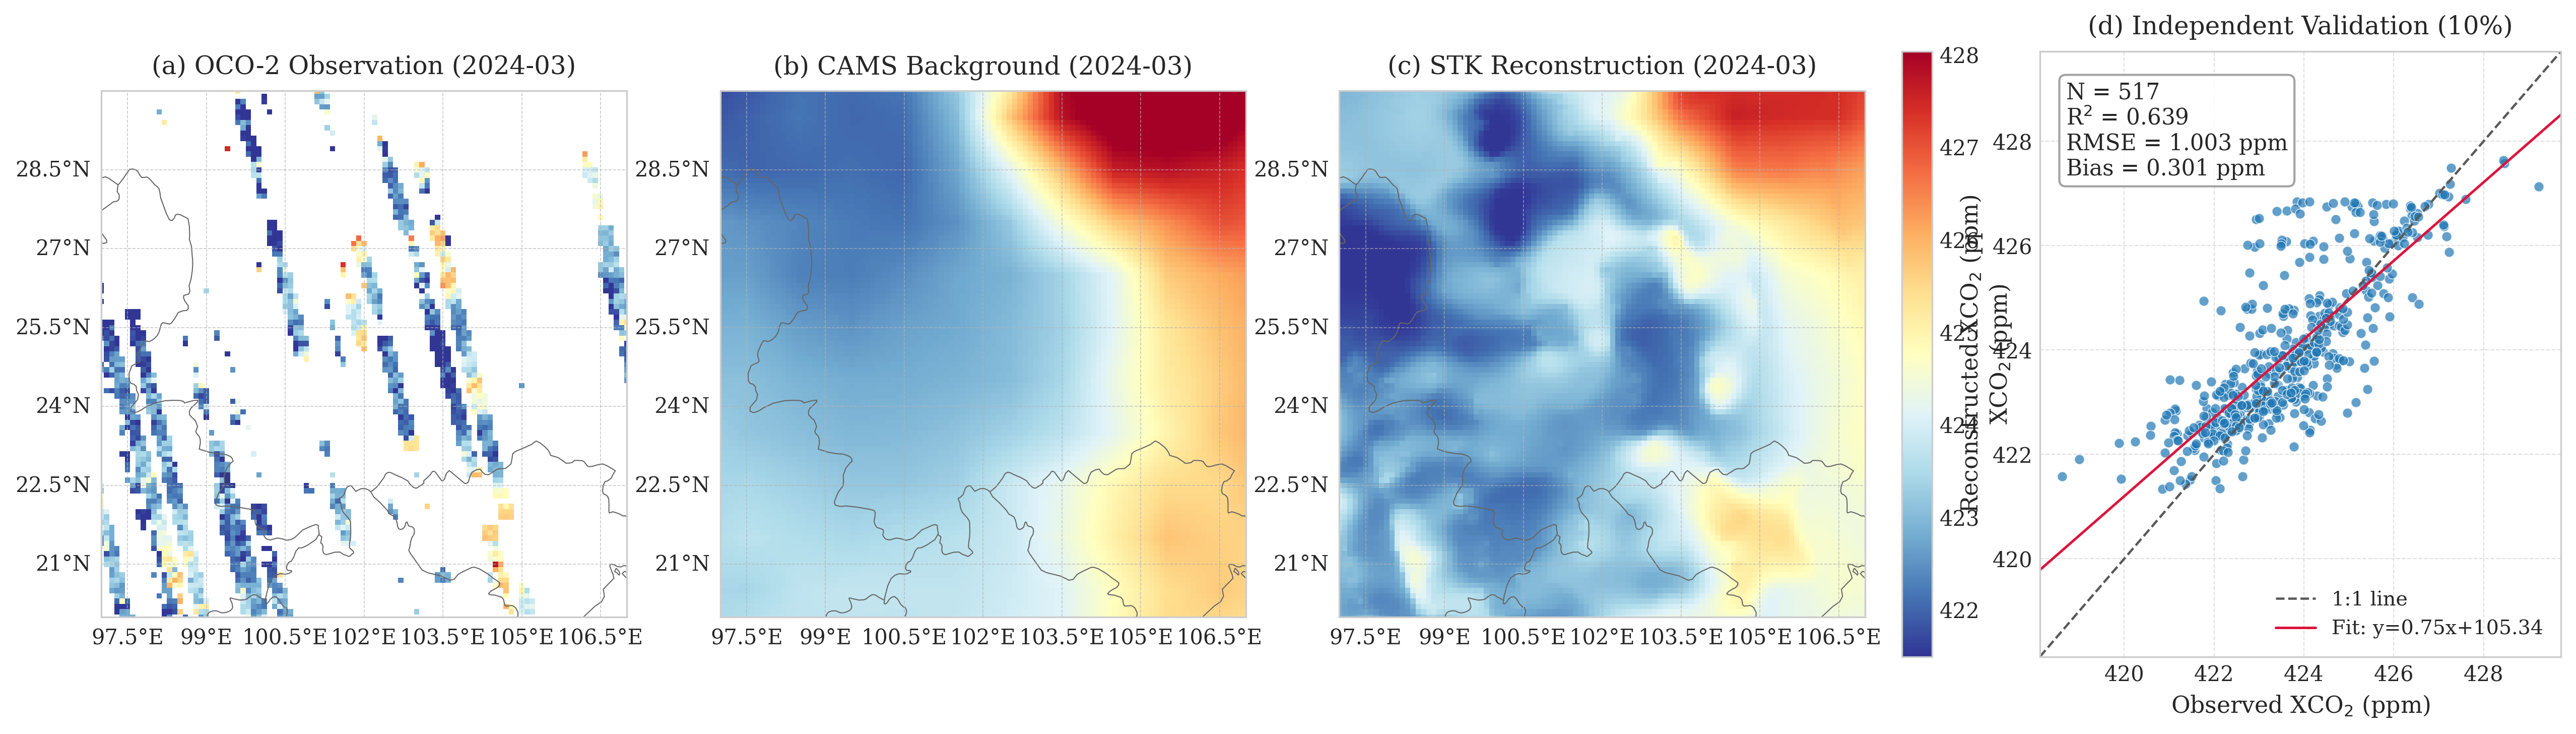

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress


print(f"[{time.strftime('%H:%M:%S')}] 正在生成 SCI 风格空间分布与独立验证图...")

# ---------- 全局绘图风格 ----------
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
mpl.rcParams["axes.linewidth"] = 0.8
mpl.rcParams["xtick.direction"] = "out"
mpl.rcParams["ytick.direction"] = "out"
mpl.rcParams["xtick.major.width"] = 0.8
mpl.rcParams["ytick.major.width"] = 0.8

# 获取本月完整原始 XCO2（包含那10%没参与插值的点）
original_xco2 = ds_o["xco2"].values[target_t_idx].astype(np.float32)

# 统一色标范围：建议基于三幅图共同范围
all_stack = np.stack([original_xco2, cams_bg, filled_xco2], axis=0)
vmin = np.nanpercentile(all_stack, 1)
vmax = np.nanpercentile(all_stack, 99)

titles = [
    f"(a) OCO-2 Observation ({target_time.strftime('%Y-%m')})",
    f"(b) CAMS Background ({target_time.strftime('%Y-%m')})",
    f"(c) STK Reconstruction ({target_time.strftime('%Y-%m')})"
]
data_list = [original_xco2, cams_bg, filled_xco2]

fig = plt.figure(figsize=(21, 5.2), dpi=300)
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.95], wspace=0.18)

map_axes = [
    fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
]
ax4 = fig.add_subplot(gs[0, 3])

# ---------- 前三幅地图 ----------
for i, ax in enumerate(map_axes):
    ax.set_extent([97, 107, 20, 30], crs=ccrs.PlateCarree())

    # 边界与底图要尽量简洁
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5, edgecolor="0.4")
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5, edgecolor="0.4")

    im = ax.pcolormesh(
        lon_g, lat_g, data_list[i],
        transform=ccrs.PlateCarree(),
        cmap="RdYlBu_r",
        vmin=vmin, vmax=vmax,
        shading="auto"
    )

    ax.set_title(titles[i], fontsize=12, pad=8, fontweight="normal")

    gl = ax.gridlines(
        draw_labels=True,
        linestyle="--",
        linewidth=0.4,
        color="0.7",
        alpha=0.7
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    # 边框细一点
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

# 共用色标
cbar = fig.colorbar(
    im,
    ax=map_axes,
    orientation="vertical",
    fraction=0.022,
    pad=0.02
)
cbar.set_label("XCO$_2$ (ppm)", fontsize=11)
cbar.ax.tick_params(labelsize=10)

# ---------- 第四幅：10% 独立验证散点图 ----------
ax4.set_title("(d) Independent Validation (10%)", fontsize=12, pad=8, fontweight="normal")

if len(val_coords) > 0:
    val_rows, val_cols = val_coords[:, 0], val_coords[:, 1]
    obs_vals = original_xco2[val_rows, val_cols]
    rec_vals = filled_xco2[val_rows, val_cols]

    valid_mask = ~np.isnan(obs_vals) & ~np.isnan(rec_vals)
    obs_vals = obs_vals[valid_mask]
    rec_vals = rec_vals[valid_mask]

    if len(obs_vals) > 1:
        rmse = np.sqrt(np.mean((rec_vals - obs_vals) ** 2))
        bias = np.mean(rec_vals - obs_vals)
        corr = np.corrcoef(obs_vals, rec_vals)[0, 1]
        r2 = corr ** 2 if not np.isnan(corr) else np.nan

        slope, intercept, _, _, _ = linregress(obs_vals, rec_vals)

        # 散点
        ax4.scatter(
            obs_vals, rec_vals,
            s=22, c="tab:blue", alpha=0.70,
            edgecolors="white", linewidths=0.4
        )

        # 1:1 线
        min_v = min(obs_vals.min(), rec_vals.min()) - 0.5
        max_v = max(obs_vals.max(), rec_vals.max()) + 0.5
        ax4.plot(
            [min_v, max_v], [min_v, max_v],
            linestyle="--", color="0.35", linewidth=1.1, label="1:1 line"
        )

        # 回归线
        xfit = np.linspace(min_v, max_v, 100)
        yfit = slope * xfit + intercept
        ax4.plot(
            xfit, yfit,
            color="crimson", linewidth=1.2,
            label=f"Fit: y={slope:.2f}x+{intercept:.2f}"
        )

        ax4.set_xlim(min_v, max_v)
        ax4.set_ylim(min_v, max_v)

        ax4.set_xlabel("Observed XCO$_2$ (ppm)", fontsize=11)
        ax4.set_ylabel("Reconstructed XCO$_2$ (ppm)", fontsize=11)

        ax4.tick_params(labelsize=10)
        ax4.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

        for spine in ax4.spines.values():
            spine.set_linewidth(0.8)

        textstr = "\n".join((
            f"N = {len(obs_vals)}",
            f"R$^2$ = {r2:.3f}",
            f"RMSE = {rmse:.3f} ppm",
            f"Bias = {bias:.3f} ppm"
        ))
        ax4.text(
            0.05, 0.95, textstr,
            transform=ax4.transAxes,
            fontsize=10.5,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.6", alpha=0.9)
        )

        ax4.legend(frameon=False, fontsize=9.5, loc="lower right")

    else:
        ax4.text(0.5, 0.5, "Insufficient validation points",
                 ha="center", va="center", fontsize=11)
else:
    ax4.text(0.5, 0.5, "No validation data",
             ha="center", va="center", fontsize=11)

# 总标题可以不要；SCI 图通常不用很大的总标题
# plt.suptitle(...)
plt.tight_layout()
plt.show()

<xarray.Dataset> Size: 17MB
Dimensions:  (time: 120, lat: 200, lon: 181)
Coordinates:
  * time     (time) datetime64[ns] 960B 2015-01-01 2015-02-01 ... 2024-12-01
  * lat      (lat) float64 2kB 15.1 15.2 15.3 15.4 15.5 ... 34.7 34.8 34.9 35.0
  * lon      (lon) float64 1kB 94.0 94.1 94.2 94.3 ... 111.7 111.8 111.9 112.0
Data variables:
    xco2     (time, lat, lon) float32 17MB ...
Attributes:
    description:    High-resolution XCO2 reconstructed using STK and CAMS bac...
    creation_date:  2026-03-27 08:10:27
使用变量: xco2
空间范围: [97, 107, 20, 30]


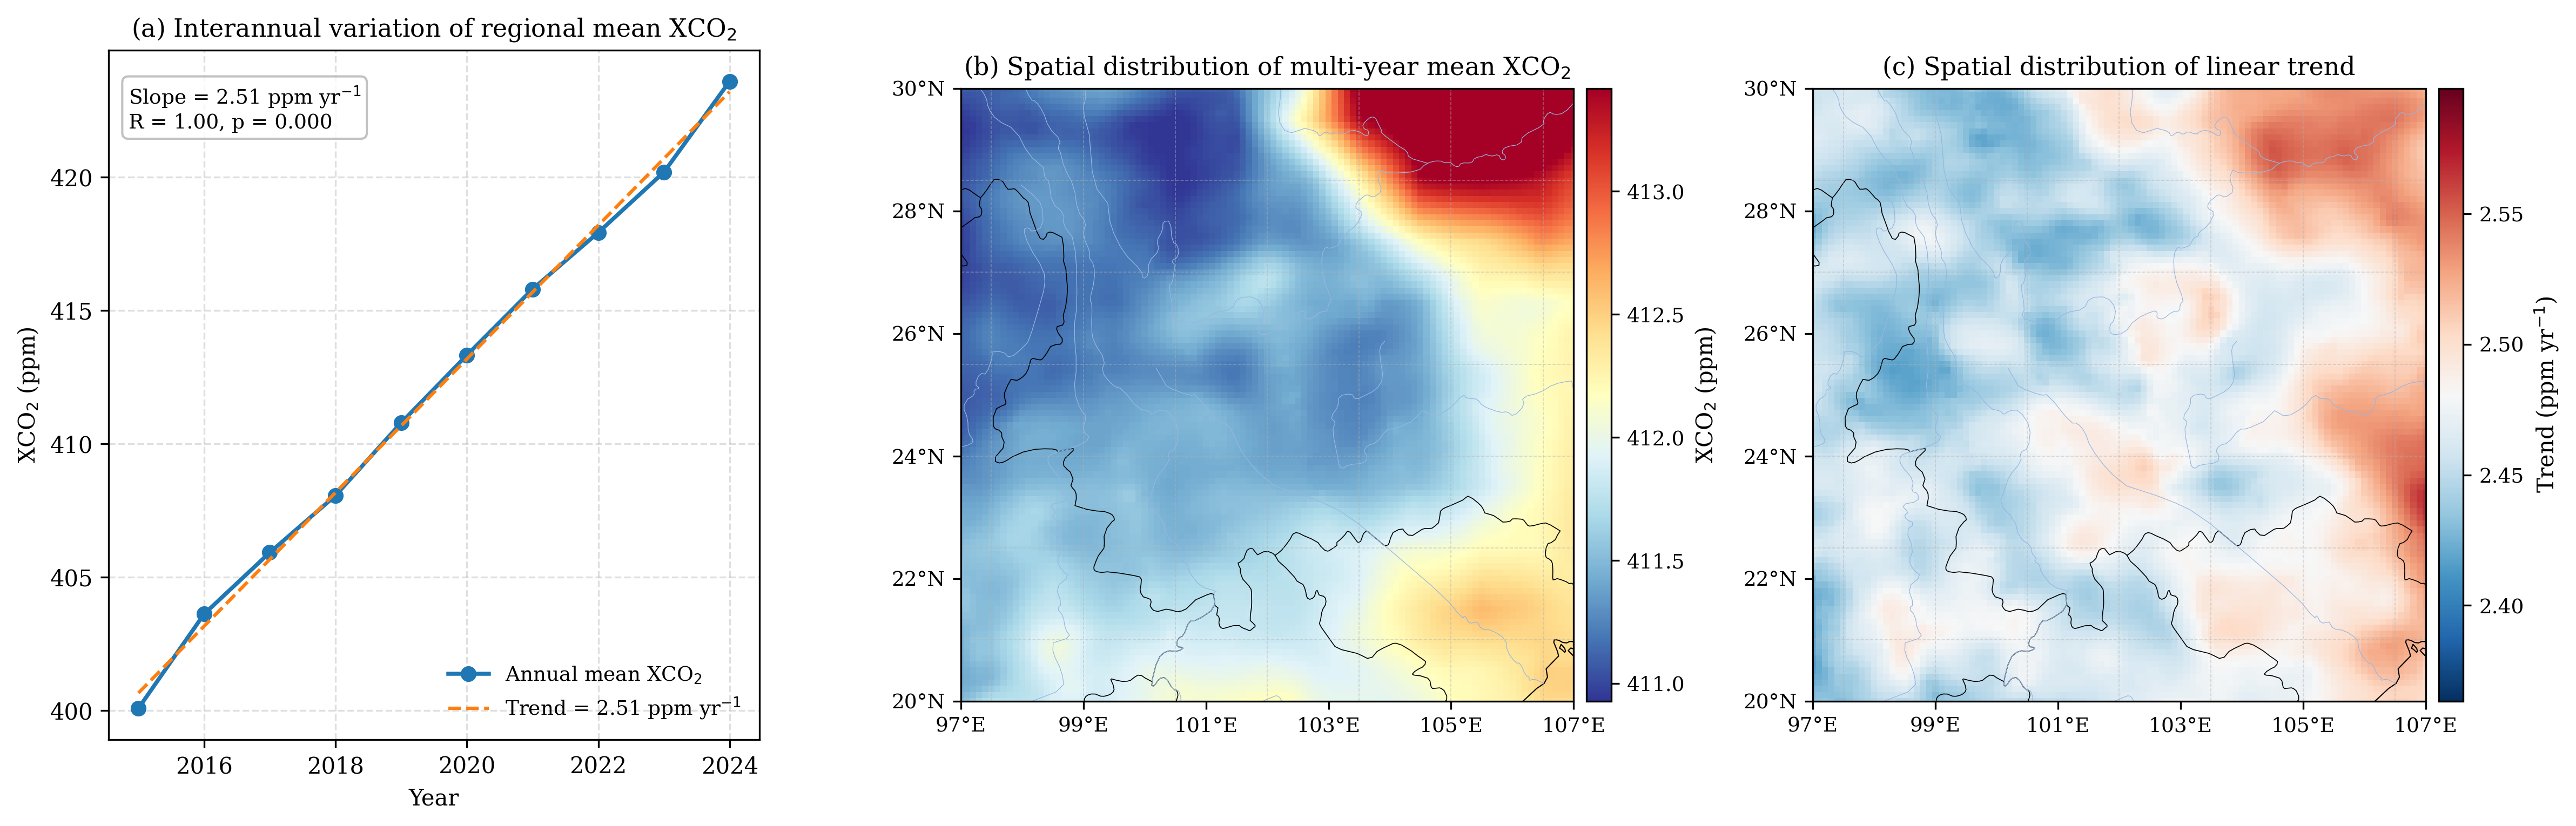

图已保存到: /content/drive/MyDrive/project_01_XCO2数据集构建/step04_stk_fill/xco2_spatiotemporal_features.png


In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import linregress

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

# =========================
# 1. 文件路径
# =========================
nc_file = oco2_xco2_month_2014_2025_stk_cn"/content/drive/MyDrive/project_01_XCO2数据集构建/step04_stk_fill/oco2_xco2_month_2015_2024_stk.nc"
out_fig = "/content/drive/MyDrive/project_01_XCO2数据集构建/step04_stk_fill/xco2_spatiotemporal_features.png"

# =========================
# 2. 读取数据
# =========================
ds = xr.open_dataset(nc_file)
print(ds)

# =========================
# 3. 自动识别变量名 / 坐标名
# =========================
def find_coord_name(ds, candidates):
    for c in candidates:
        if c in ds.coords:
            return c
    for c in candidates:
        if c in ds.variables:
            return c
    return None

time_name = find_coord_name(ds, ["time", "Time", "date", "datetime"])
lat_name  = find_coord_name(ds, ["lat", "latitude", "y", "LAT", "Latitude"])
lon_name  = find_coord_name(ds, ["lon", "longitude", "x", "LON", "Longitude"])

if time_name is None or lat_name is None or lon_name is None:
    raise ValueError("未能自动识别 time / lat / lon，请先 print(ds) 查看实际变量名。")

# 自动找主变量（优先找 xco2）
data_var = None
priority_vars = ["xco2", "XCO2", "oco2_xco2", "stk_xco2", "co2"]
for v in priority_vars:
    if v in ds.data_vars:
        data_var = v
        break

if data_var is None:
    # 找到第一个同时包含 time/lat/lon 维度的变量
    for v in ds.data_vars:
        dims = ds[v].dims
        if time_name in dims and lat_name in dims and lon_name in dims:
            data_var = v
            break

if data_var is None:
    raise ValueError("未找到包含 time/lat/lon 的主数据变量，请手动指定。")

da = ds[data_var]
print(f"使用变量: {data_var}")

# =========================
# 4. 数据预处理
# =========================
# 保证维度顺序统一
da = da.transpose(time_name, lat_name, lon_name)

# 若时间不是 datetime，尝试解码
if not np.issubdtype(da[time_name].dtype, np.datetime64):
    try:
        ds = xr.decode_cf(ds)
        da = ds[data_var].transpose(time_name, lat_name, lon_name)
        print("时间已自动解码为 datetime。")
    except Exception as e:
        print("时间未成功自动解码，将按原始时间处理：", e)

# 经纬度
lon = da[lon_name]
lat = da[lat_name]

# 空间范围
extent = [90,145,-10,30]
print("空间范围:", extent)

# =========================
# 5. 子图1：区域均值年际变化
# =========================
# 月尺度先求区域平均，再聚合成年平均
regional_monthly = da.mean(dim=[lat_name, lon_name], skipna=True)

if np.issubdtype(regional_monthly[time_name].dtype, np.datetime64):
    annual_mean = regional_monthly.groupby(f"{time_name}.year").mean(skipna=True)
    years = annual_mean["year"].values
    annual_values = annual_mean.values
else:
    raise ValueError("time 不是 datetime 类型，建议先检查时间坐标。")

# 拟合趋势线
mask_valid = np.isfinite(annual_values)
years_fit = years[mask_valid]
vals_fit = annual_values[mask_valid]

slope_ts, intercept_ts, r_ts, p_ts, std_ts = linregress(years_fit, vals_fit)
trend_line = slope_ts * years_fit + intercept_ts

# =========================
# 6. 子图2：多年均值空间分布
# =========================
mean_map = da.mean(dim=time_name, skipna=True)

# =========================
# 7. 子图3：线性变化率（ppm/yr）
# =========================
# 用月序列逐像元线性回归，最后换算为 ppm/yr
# 若时间是按月均匀序列，直接用“年小数”更稳妥
time_coord = da[time_name]
year_decimal = (
    time_coord.dt.year + (time_coord.dt.month - 1) / 12.0
).values.astype(float)

data_3d = da.values   # shape: (time, lat, lon)
nt, ny, nx = data_3d.shape

slope_map = np.full((ny, nx), np.nan, dtype=np.float32)
p_map     = np.full((ny, nx), np.nan, dtype=np.float32)

for i in range(ny):
    for j in range(nx):
        y = data_3d[:, i, j]
        m = np.isfinite(y) & np.isfinite(year_decimal)
        if m.sum() >= 6:
            res = linregress(year_decimal[m], y[m])
            slope_map[i, j] = res.slope      # ppm/yr
            p_map[i, j] = res.pvalue

slope_da = xr.DataArray(
    slope_map,
    coords={lat_name: lat, lon_name: lon},
    dims=(lat_name, lon_name),
    name="linear_trend"
)

p_da = xr.DataArray(
    p_map,
    coords={lat_name: lat, lon_name: lon},
    dims=(lat_name, lon_name),
    name="p_value"
)

# =========================
# 8. 绘图辅助函数
# =========================
def add_map_features(ax, extent):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.4)
    ax.add_feature(cfeature.LAKES.with_scale("50m"), linewidth=0.3, facecolor="none")
    ax.add_feature(cfeature.RIVERS.with_scale("50m"), linewidth=0.3)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.4,
        linestyle="--",
        alpha=0.5
    )

    xticks = np.arange(np.floor(extent[0]), np.ceil(extent[1]) + 1, 2)
    yticks = np.arange(np.floor(extent[2]), np.ceil(extent[3]) + 1, 2)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=9)

def add_colorbar(fig, ax, mappable, label):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08, axes_class=plt.Axes)
    cb = fig.colorbar(mappable, cax=cax)
    cb.set_label(label, fontsize=10)
    cb.ax.tick_params(labelsize=9)
    return cb

# =========================
# 9. 配色范围
# =========================
# 多年均值：稳健显示
mean_vmin = float(np.nanpercentile(mean_map.values, 2))
mean_vmax = float(np.nanpercentile(mean_map.values, 98))

# 趋势图：对称色标更适合
slope_abs = float(np.nanpercentile(np.abs(slope_da.values), 98))
slope_vmin, slope_vmax = -slope_abs, slope_abs

# =========================
# 10. 作图
# =========================
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["axes.unicode_minus"] = False

fig = plt.figure(figsize=(16, 5.2), dpi=300)

# ---- 子图1：区域均值年际变化 ----
ax1 = fig.add_subplot(1, 3, 1)

ax1.plot(years, annual_values, marker="o", linewidth=1.8, label="Annual mean XCO$_2$")
ax1.plot(years_fit, trend_line, linestyle="--", linewidth=1.5,
         label=f"Trend = {slope_ts:.2f} ppm yr$^{{-1}}$")

ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("XCO$_2$ (ppm)", fontsize=10)
ax1.set_title("(a) Interannual variation of regional mean XCO$_2$", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(fontsize=9, frameon=False)

text_str = f"Slope = {slope_ts:.2f} ppm yr$^{{-1}}$\nR = {r_ts:.2f}, p = {p_ts:.3f}"
ax1.text(0.03, 0.95, text_str, transform=ax1.transAxes,
         ha="left", va="top", fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="0.7"))

# ---- 子图2：多年均值空间分布 ----
ax2 = fig.add_subplot(1, 3, 2, projection=ccrs.PlateCarree())
add_map_features(ax2, extent)

im2 = ax2.pcolormesh(
    lon, lat, mean_map,
    transform=ccrs.PlateCarree(),
    cmap="RdYlBu_r",
    shading="auto",
    vmin=mean_vmin,
    vmax=mean_vmax
)
ax2.set_title("(b) Spatial distribution of multi-year mean XCO$_2$", fontsize=11)
add_colorbar(fig, ax2, im2, "XCO$_2$ (ppm)")

# ---- 子图3：线性变化率 ----
ax3 = fig.add_subplot(1, 3, 3, projection=ccrs.PlateCarree())
add_map_features(ax3, extent)

im3 = ax3.pcolormesh(
    lon, lat, slope_da,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    shading="auto",

)
'''
# 可选：叠加显著性点
sig_mask = p_da.values < 0.05
yy, xx = np.where(sig_mask)
if len(xx) > 0:
    ax3.scatter(
        lon.values[xx],
        lat.values[yy],
        s=3, c="k", marker=".",
        transform=ccrs.PlateCarree(),
        alpha=0.6
    )
'''
ax3.set_title("(c) Spatial distribution of linear trend", fontsize=11)
add_colorbar(fig, ax3, im3, "Trend (ppm yr$^{-1}$)")

plt.tight_layout()
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"图已保存到: {out_fig}")

#重建数据验证： oco3数据

[16:24:44] 正在读取 OCO-3 观测数据...
[16:24:45] 正在读取 STK 重建数据...

[16:24:45] 🎬 开始执行基于 OCO-3 的外部验证...
[16:24:45] 找到 72 个匹配的月份。
[16:24:45] 正在将 OCO-3 空间网格对齐至 STK (基于最近邻插值)...
[16:24:46] 空间对齐完成！开始逐月精度比对...
[16:24:47] 总体指标 -> N: 1040563, R²: 0.934, RMSE: 1.197, Bias: -0.201


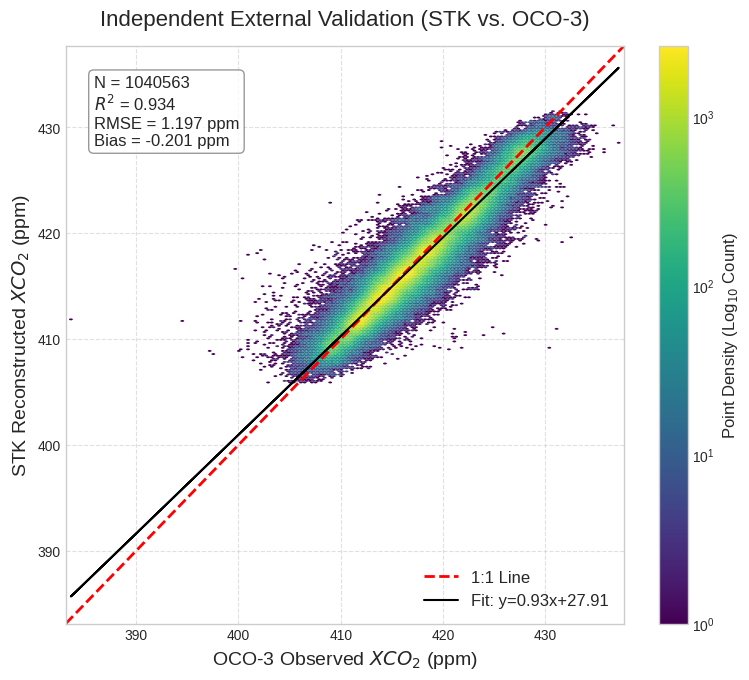

[16:24:49] 密度散点图已保存至: /content/drive/MyDrive/project_01_XCO2数据集构建/step05_Validation/OCO3_Validation_DensityScatter.png
[16:24:49] 月度指标已保存至: /content/drive/MyDrive/project_01_XCO2数据集构建/step05_Validation/OCO3_Validation_Metrics.csv

[16:24:49] ✅ OCO-3 外部验证全部完成，总耗时: 4.18 秒。


In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm  # 用于对数刻度颜色条
import time
from pathlib import Path
from scipy.stats import pearsonr


def validate_reconstruction_with_oco3(ds_stk, ds_oco3, OUT_PATH):
    """
    使用 OCO-3 独立观测数据验证 STK 重构的 XCO2 结果 (带自动空间对齐和高密度散点图优化)。
    """
    OUT_PATH = Path(OUT_PATH)
    OUT_PATH.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # 1. 时间和空间网格对齐
    # ---------------------------------------------------------

    # 提取共有时间范围 (取交集)
    stk_times = ds_stk['time'].values
    oco3_times = ds_oco3['time'].values
    common_times = np.intersect1d(stk_times, oco3_times)

    if len(common_times) == 0:
        print("⚠️ 警告：STK 重建数据与 OCO-3 数据没有重合的时间月份！")
        return None

    print(f"[{time.strftime('%H:%M:%S')}] 找到 {len(common_times)} 个匹配的月份。")

    # 自动识别经纬度坐标名称（兼容 'lon'/'lat' 或 'longitude'/'latitude'）
    lon_name = 'lon' if 'lon' in ds_stk.coords else 'longitude'
    lat_name = 'lat' if 'lat' in ds_stk.coords else 'latitude'

    print(f"[{time.strftime('%H:%M:%S')}] 正在将 OCO-3 空间网格对齐至 STK (基于最近邻插值)...")
    # 仅保留共有时间
    ds_stk_common = ds_stk.sel(time=common_times)
    ds_oco3_common = ds_oco3.sel(time=common_times)

    # 将 OCO-3 插值到 STK 的经纬度网格上
    # 使用 method='nearest' 确保我们取的是最近的真实观测值，而不是线性插值造出来的虚假值
    ds_oco3_aligned = ds_oco3_common.interp(
        {lon_name: ds_stk_common[lon_name], lat_name: ds_stk_common[lat_name]},
        method='nearest'
    )
    print(f"[{time.strftime('%H:%M:%S')}] 空间对齐完成！开始逐月精度比对...")

    # 用于存储所有匹配上的像元值，绘制整体散点图
    all_stk_vals = []
    all_oco3_vals = []

    # 用于记录每月的统计指标
    monthly_metrics = []

    for t in common_times:
        # 提取当月数据 (假设变量名均为 'xco2')
        stk_month = ds_stk_common['xco2'].sel(time=t).values.flatten()
        oco3_month = ds_oco3_aligned['xco2'].sel(time=t).values.flatten()

        # 寻找两者同时有效的像元 (非 NaN)
        valid_mask = np.isfinite(stk_month) & np.isfinite(oco3_month)

        stk_valid = stk_month[valid_mask]
        oco3_valid = oco3_month[valid_mask]

        n_points = len(stk_valid)
        if n_points > 0:
            all_stk_vals.extend(stk_valid)
            all_oco3_vals.extend(oco3_valid)

            # 计算当月指标
            r, _ = pearsonr(oco3_valid, stk_valid)
            r2 = r**2
            rmse = np.sqrt(np.mean((stk_valid - oco3_valid)**2))
            bias = np.mean(stk_valid - oco3_valid)

            monthly_metrics.append({
                'Time': pd.to_datetime(t).strftime('%Y-%m'),
                'N_Points': n_points,
                'R2': r2,
                'RMSE': rmse,
                'Bias': bias
            })

    # 转换为 DataFrame 方便保存和查看
    df_metrics = pd.DataFrame(monthly_metrics)

    # 将整体数据转为 numpy 数组计算全局指标
    all_stk_arr = np.array(all_stk_vals)
    all_oco3_arr = np.array(all_oco3_vals)

    total_n = len(all_stk_arr)
    if total_n == 0:
        print("⚠️ 警告：虽然时间重合，但在空间上没有找到任何同时有效的像元！检查一下两个数据的范围是否有交集。")
        return df_metrics

    global_r, _ = pearsonr(all_oco3_arr, all_stk_arr)
    global_r2 = global_r**2
    global_rmse = np.sqrt(np.mean((all_stk_arr - all_oco3_arr)**2))
    global_bias = np.mean(all_stk_arr - all_oco3_arr)

    print(f"[{time.strftime('%H:%M:%S')}] 总体指标 -> N: {total_n}, R²: {global_r2:.3f}, RMSE: {global_rmse:.3f}, Bias: {global_bias:.3f}")

    # ---------------------------------------------------------
    # 🌟 🌟 2. 绘制优化后的密度散点图 (Density Scatter Plot) 🌟 🌟
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 7.5))

    # 设置坐标轴范围
    min_val = min(np.nanmin(all_oco3_arr), np.nanmin(all_stk_arr)) - 0.5
    max_val = max(np.nanmax(all_oco3_arr), np.nanmax(all_stk_arr)) + 0.5

    # --- 核心修改：使用 hexbin 绘制密度图 ---
    # gridsize: 六边形格子的数量。越大越精细，太小会变成马赛克。100-200比较合适。
    # cmap: 颜色映射，'viridis' 或 'magma' 是SCI常用的感知均匀色带，比 'jet' 好。
    # mincnt: 最小计数，少于这个点数的格子不显示（保持背景白色）。
    # bins: 'log' 使用对数刻度颜色条，能同时看清高密度和低密度区域。
    hb = ax.hexbin(
        all_oco3_arr,
        all_stk_arr,
        gridsize=150,
        cmap='viridis',
        mincnt=1,
        bins='log',
        edgecolors='none'
    )

    # 添加颜色条，并设置标签
    cb = fig.colorbar(hb, ax=ax, label='Point Density (Log$_{10}$ Count)')
    cb.set_label('Point Density (Log$_{10}$ Count)', fontsize=12)

    # 1:1 参考线
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

    # 拟合线
    z = np.polyfit(all_oco3_arr, all_stk_arr, 1)
    p = np.poly1d(z)
    ax.plot(all_oco3_arr, p(all_oco3_arr), 'k-', lw=1.5, label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}')

    # 指标文本框
    textstr = '\n'.join((
        f'N = {total_n}',
        f'$R^2$ = {global_r2:.3f}',
        f'RMSE = {global_rmse:.3f} ppm',
        f'Bias = {global_bias:.3f} ppm'
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
             verticalalignment='top', bbox=props)

    ax.set_xlabel('OCO-3 Observed $XCO_2$ (ppm)', fontsize=14)
    ax.set_ylabel('STK Reconstructed $XCO_2$ (ppm)', fontsize=14)
    ax.set_title('Independent External Validation (STK vs. OCO-3)', fontsize=16, pad=15)
    ax.set_xlim([min_val, max_val])
    ax.set_ylim([min_val, max_val])
    ax.legend(loc='lower right', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)

    # ---------------------------------------------------------
    # 3. 保存与显示
    # ---------------------------------------------------------

    # 保存图表和 CSV
    plot_path = OUT_PATH / "OCO3_Validation_DensityScatter.png"
    csv_path = OUT_PATH / "OCO3_Validation_Metrics.csv"

    # 1. 保存高清图片 (dpi=300 达到发表标准)
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')

    # 2. 在屏幕上显示图片
    plt.show()

    # 3. 关闭画布释放内存
    plt.close()

    df_metrics.to_csv(csv_path, index=False)
    print(f"[{time.strftime('%H:%M:%S')}] 密度散点图已保存至: {plot_path}")
    print(f"[{time.strftime('%H:%M:%S')}] 月度指标已保存至: {csv_path}")

    return df_metrics

# 请确保你的 Google Drive 已挂载
oco3_nc = PROJECT_DIR / "step03_谐波订正/oco3_xco2_month_201908_202512.nc"
stk_nc = PROJECT_DIR / "step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc"

try:
    print(f"[{time.strftime('%H:%M:%S')}] 正在读取 OCO-3 观测数据...")
    ds_oco3_raw = xr.open_dataset(oco3_nc)

    print(f"[{time.strftime('%H:%M:%S')}] 正在读取 STK 重建数据...")
    ds_stk_all = xr.open_dataset(stk_nc)
except FileNotFoundError as e:
    print(f"\n⚠️ 文件读取失败！请检查文件路径是否正确：\n{e}")
    ds_oco3_raw = None
    ds_stk_all = None

# 在 Google Drive 里创建一个专门存验证结果的文件夹
validation_OUT_PATH = Path("/content/drive/MyDrive/project_01_XCO2数据集构建/step05_Validation")

if ds_oco3_raw is not None and ds_stk_all is not None:
    print(f"\n[{time.strftime('%H:%M:%S')}] 🎬 开始执行基于 OCO-3 的外部验证...")
    start_val_time = time.time()

    val_summary_df = validate_reconstruction_with_oco3(
        ds_stk_all,
        ds_oco3_raw,
        validation_OUT_PATH
    )

    end_val_time = time.time() - start_val_time
    print(f"\n[{time.strftime('%H:%M:%S')}] ✅ OCO-3 外部验证全部完成，总耗时: {end_val_time:.2f} 秒。")

    # 用完后关闭 Dataset 释放内存
    ds_oco3_raw.close()
    ds_stk_all.close()
else:
    print("⚠️ 警告：数据读取失败，程序终止。")

#  重建数据验证：香格里拉

[16:29:54] 🎬 开始执行香格里拉单站点时间序列验证...
[16:29:54] 成功读取地面数据，正在执行严密的质量控制与时段过滤...
[16:29:54] 过滤完成！成功转换为月均值，共获取 161 个高质量代表性月份。
[16:29:54] 正在从 STK 网格中提取 Shangri-La (XGL) 的时间序列...
[16:29:54] 匹配成功！共 120 个重合月份。
指标统计 -> R²: 0.947, RMSE: 3.120 ppm, Bias: -2.497 ppm


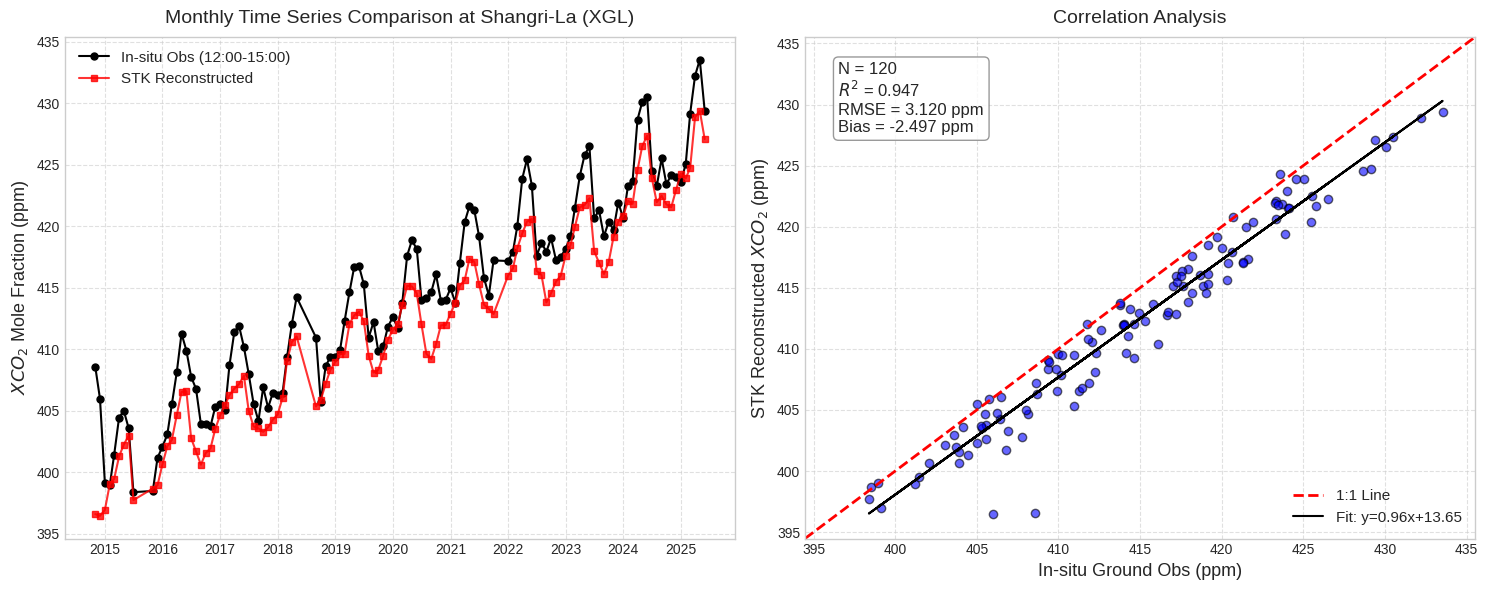

[16:29:55] ✅ 验证完成！图表已保存至: /content/drive/MyDrive/东南亚数据集/step05_Validation/ShangriLa_Validation_TimeSeries.png


NameError: name 'csv_fn' is not defined

In [ ]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr
import time
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

csv_path = "/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/yunnan_insitu/XGL_hour_avg_56449_picarro_L2_CO2_2009010100_2025063023.csv"
stk_nc = PROJECT_DIR / "step04_stk_fill/oco2_xco2_month_2014_2025_stk_cn.nc"
OUT_PATH = PROJECT_DIR /"step05_Validation"
OUT_PATH.mkdir(parents=True, exist_ok=True)

STATION_NAME = "Shangri-La (XGL)"
STATION_LON = 99.73
STATION_LAT = 27.83

print(f"[{time.strftime('%H:%M:%S')}] 🎬 开始执行香格里拉单站点时间序列验证...")

try:
    df_xgl_hourly = pd.read_csv(csv_path, encoding='gb18030')
    time_col = '观测时间'
    co2_col = '浓度'
    qc_col = '最终质控码'

    print(f"[{time.strftime('%H:%M:%S')}] 成功读取地面数据，正在执行严密的质量控制与时段过滤...")

    df_xgl_hourly[time_col] = pd.to_datetime(df_xgl_hourly[time_col])
    df_xgl_hourly.set_index(time_col, inplace=True)

    if qc_col in df_xgl_hourly.columns:
        df_xgl_hourly = df_xgl_hourly[df_xgl_hourly[qc_col] == 0]

    df_xgl_hourly = df_xgl_hourly[(df_xgl_hourly.index.hour >= 10) & (df_xgl_hourly.index.hour <= 14)]
    df_xgl_hourly = df_xgl_hourly[(df_xgl_hourly[co2_col] > 350) & (df_xgl_hourly[co2_col] < 500)]

    df_xgl_monthly = df_xgl_hourly[co2_col].resample('MS').mean().dropna().reset_index()
    df_xgl_monthly.columns = ['time', 'InSitu_CO2']
    df_xgl_monthly['time'] = df_xgl_monthly['time'].dt.to_period('M')

    print(f"[{time.strftime('%H:%M:%S')}] 过滤完成！成功转换为月均值，共获取 {len(df_xgl_monthly)} 个高质量代表性月份。")

except Exception as e:
    print(f"⚠️ 读取地面 CSV 数据失败：\n{e}")
    raise

try:
    ds_stk = xr.open_dataset(stk_nc)
    lon_name = 'lon' if 'lon' in ds_stk.coords else 'longitude'
    lat_name = 'lat' if 'lat' in ds_stk.coords else 'latitude'

    print(f"[{time.strftime('%H:%M:%S')}] 正在从 STK 网格中提取 {STATION_NAME} 的时间序列...")

    stk_station = ds_stk['xco2'].sel({lon_name: STATION_LON, lat_name: STATION_LAT}, method='nearest')
    df_stk_ts = stk_station.to_dataframe().reset_index()
    df_stk_ts = df_stk_ts[['time', 'xco2']].dropna()
    df_stk_ts.columns = ['time', 'STK_XCO2']
    df_stk_ts['time'] = df_stk_ts['time'].dt.to_period('M')

except Exception as e:
    print(f"⚠️ 提取 STK 数据失败：{e}")
    raise
finally:
    if 'ds_stk' in locals():
        ds_stk.close()

df_merged = pd.merge(df_xgl_monthly, df_stk_ts, on='time', how='inner')
n_months = len(df_merged)
df_merged['time'] = df_merged['time'].dt.to_timestamp()

if n_months == 0:
    print("⚠️ 警告：地面数据与 STK 重建数据没有重合的时间段！请检查时间范围。")
else:
    r, p_val = pearsonr(df_merged['InSitu_CO2'], df_merged['STK_XCO2'])
    r2 = r**2
    rmse = np.sqrt(np.mean((df_merged['STK_XCO2'] - df_merged['InSitu_CO2'])**2))
    bias = np.mean(df_merged['STK_XCO2'] - df_merged['InSitu_CO2'])

    print(f"[{time.strftime('%H:%M:%S')}] 匹配成功！共 {n_months} 个重合月份。")
    print(f"指标统计 -> R²: {r2:.3f}, RMSE: {rmse:.3f} ppm, Bias: {bias:.3f} ppm")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1]})

    ax1.plot(df_merged['time'], df_merged['InSitu_CO2'], 'o-', color='black', linewidth=1.5, markersize=5, label='In-situ Obs (12:00-15:00)')
    ax1.plot(df_merged['time'], df_merged['STK_XCO2'], 's-', color='red', linewidth=1.5, markersize=5, alpha=0.8, label='STK Reconstructed')
    ax1.set_title(f'Monthly Time Series Comparison at {STATION_NAME}', fontsize=14, pad=10)
    ax1.set_ylabel('$XCO_2$ Mole Fraction (ppm)', fontsize=13)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='upper left', fontsize=11)
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    min_val = min(df_merged['InSitu_CO2'].min(), df_merged['STK_XCO2'].min()) - 2
    max_val = max(df_merged['InSitu_CO2'].max(), df_merged['STK_XCO2'].max()) + 2

    ax2.scatter(df_merged['InSitu_CO2'], df_merged['STK_XCO2'], color='blue', alpha=0.6, edgecolor='k')
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

    z = np.polyfit(df_merged['InSitu_CO2'], df_merged['STK_XCO2'], 1)
    p = np.poly1d(z)
    ax2.plot(df_merged['InSitu_CO2'], p(df_merged['InSitu_CO2']), 'k-', lw=1.5, label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}')

    textstr = '\n'.join((
        f'N = {n_months}',
        f'$R^2$ = {r2:.3f}',
        f'RMSE = {rmse:.3f} ppm',
        f'Bias = {bias:.3f} ppm'
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=12, verticalalignment='top', bbox=props)

    ax2.set_xlabel('In-situ Ground Obs (ppm)', fontsize=13)
    ax2.set_ylabel('STK Reconstructed $XCO_2$ (ppm)', fontsize=13)
    ax2.set_title('Correlation Analysis', fontsize=14, pad=10)
    ax2.set_xlim([min_val, max_val])
    ax2.set_ylim([min_val, max_val])
    ax2.legend(loc='lower right', fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    plot_path = OUT_PATH / "ShangriLa_Validation_TimeSeries.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"[{time.strftime('%H:%M:%S')}] ✅ 验证完成！图表已保存至: {plot_path}")

csn_fn="/content/drive/MyDrive/project_01_XCO2数据集构建/step05_Validation/香格里拉_oco2.csv"
df_merged.to_csv(csv_fn, index=False)
print(f"📄 匹配数据已保存至: {csv_fn}")



# *重建数据验证：合肥*

R²   = 0.983
RMSE = 1.153 ppm
MAE  = 0.917 ppm
MB   = 0.687 ppm


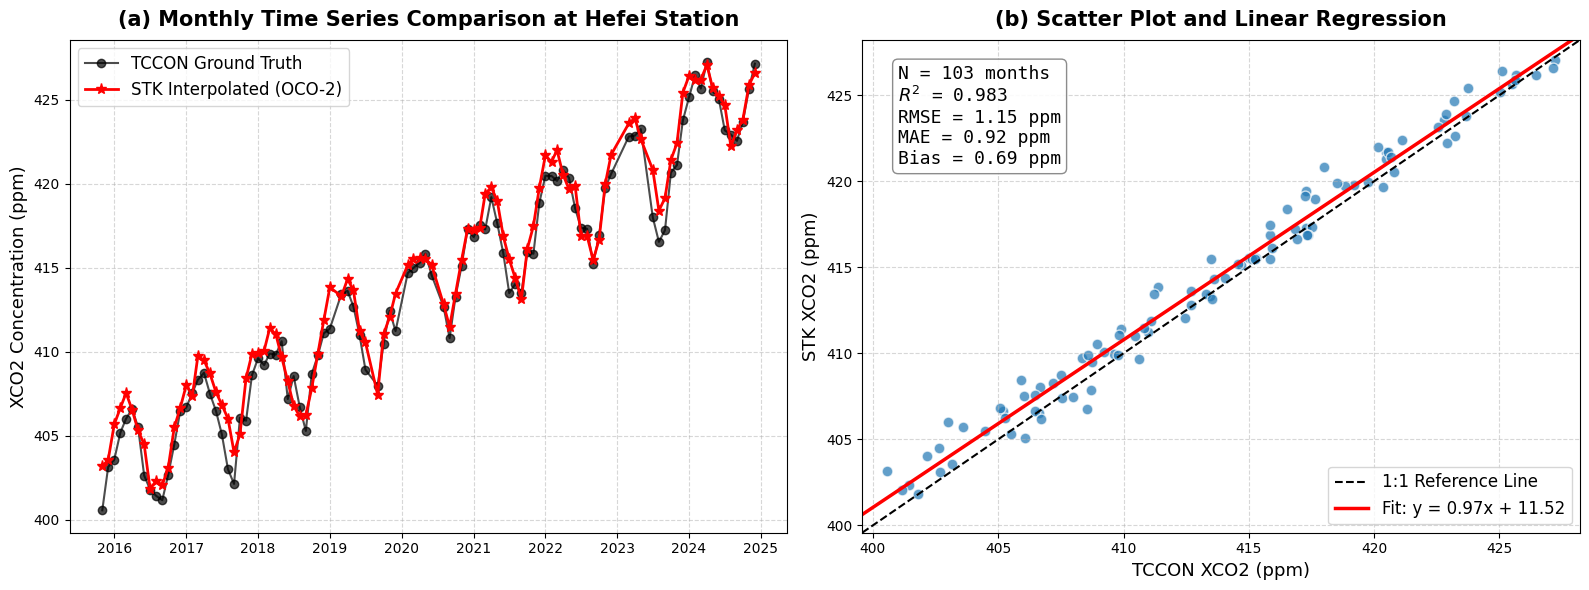

/content/drive/MyDrive/project_01_XCO2数据集构建/step05_Validation/tccon_hf_oco2.csv


In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

stk_nc = "/content/drive/MyDrive/project_01_XCO2数据集构建/step04_stk_fill/oco2_xco2_month_2015_2024_stk_cn.nc"
tccon_file = "/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/TCCON/hf20151102_20241229.public.qc.nc"

HEFEI_LAT = 31.926
HEFEI_LON = 117.165

ds_stk = xr.open_dataset(stk_nc)
stk_hefei = ds_stk['xco2'].sel(lat=HEFEI_LAT, lon=HEFEI_LON, method='nearest')

df_stk = stk_hefei.to_dataframe().reset_index()
df_stk = df_stk[['time', 'xco2']].rename(columns={'xco2': 'STK_XCO2'})
df_stk['time'] = pd.to_datetime(df_stk['time'])
df_stk.set_index('time', inplace=True)
df_stk.index = df_stk.index.to_period('M')

ds_tccon = xr.open_dataset(tccon_file)
tccon_time = ds_tccon['time'].values
tccon_xco2 = ds_tccon['xco2'].values

df_tccon_raw = pd.DataFrame({'time': tccon_time, 'TCCON_XCO2': tccon_xco2})
df_tccon_raw.set_index('time', inplace=True)
df_tccon_raw = df_tccon_raw.dropna()

df_tccon = df_tccon_raw.resample('ME').mean()
df_tccon.index = df_tccon.index.to_period('M')

df_matched = df_stk.join(df_tccon, how='inner').dropna()
df_matched.index = df_matched.index.to_timestamp()

stk_vals = df_matched['STK_XCO2'].values
tccon_vals = df_matched['TCCON_XCO2'].values

rmse = np.sqrt(mean_squared_error(tccon_vals, stk_vals))
mae = mean_absolute_error(tccon_vals, stk_vals)
mb = np.mean(stk_vals - tccon_vals)
slope, intercept, r_value, p_value, std_err = stats.linregress(tccon_vals, stk_vals)
r2 = r_value ** 2

print(f"R²   = {r2:.3f}")
print(f"RMSE = {rmse:.3f} ppm")
print(f"MAE  = {mae:.3f} ppm")
print(f"MB   = {mb:.3f} ppm")

fig = plt.figure(figsize=(16, 6))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(df_matched.index, df_matched['TCCON_XCO2'], 'ko-', label='TCCON Ground Truth', alpha=0.7, markersize=6)
ax1.plot(df_matched.index, df_matched['STK_XCO2'], 'r*-', label='STK Interpolated (OCO-2)', linewidth=2, markersize=8)
ax1.set_title('(a) Monthly Time Series Comparison at Hefei Station', fontsize=15, fontweight='bold', pad=10)
ax1.set_ylabel('XCO2 Concentration (ppm)', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', fontsize=12)

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(tccon_vals, stk_vals, c='tab:blue', alpha=0.7, edgecolors='white', s=60)
min_val = min(tccon_vals.min(), stk_vals.min()) - 1
max_val = max(tccon_vals.max(), stk_vals.max()) + 1
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='1:1 Reference Line')
fit_line = slope * np.array([min_val, max_val]) + intercept
ax2.plot([min_val, max_val], fit_line, 'r-', linewidth=2.5, label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')
ax2.set_xlim([min_val, max_val])
ax2.set_ylim([min_val, max_val])
ax2.set_title('(b) Scatter Plot and Linear Regression', fontsize=15, fontweight='bold', pad=10)
ax2.set_xlabel('TCCON XCO2 (ppm)', fontsize=13)
ax2.set_ylabel('STK XCO2 (ppm)', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right', fontsize=12)

text_str = '\n'.join((
    f'N = {len(df_matched)} months',
    f'$R^2$ = {r2:.3f}',
    f'RMSE = {rmse:.2f} ppm',
    f'MAE = {mae:.2f} ppm',
    f'Bias = {mb:.2f} ppm'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax2.text(0.05, 0.95, text_str, transform=ax2.transAxes, fontsize=13, verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()
csn_fn="/content/drive/MyDrive/project_01_XCO2数据集构建/step05_Validation/tccon_hf_oco2.csv"
df_matched.to_csv(csn_fn)
print(csn_fn)